In [1]:
# Install required libraries
!pip install gdown pandas numpy matplotlib seaborn scikit-learn torch torchvision torchaudio --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
import gdown
import os
from datetime import datetime
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Configure device - CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*70)
print("SYSTEM CONFIGURATION")
print("="*70)
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Device Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
print(f"Using device: {device}")
print("="*70)


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
SYSTEM CONFIGURATION
PyTorch Version: 2.9.0+cu128
CUDA Available: True
CUDA Version: 12.8
Device Name: NVIDIA H200
Device Memory: 139.81 GB
Using device: cuda


In [2]:
print("="*70)
print("LOADING DATA AND IDENTIFYING ATTACK-RELATED SENSORS")
print("="*70)

# Load datasets
df_train = pd.read_csv('wadi_dataset/WADI_14days.csv')
df_test = pd.read_csv('wadi_dataset/WADI_attackdata.csv')

print(f"\nOriginal Data Shapes:")
print(f"  Training:  {df_train.shape}")
print(f"  Testing:   {df_test.shape}")

# Extract attack-related sensors from table_WADI.pdf
# These are the ACTUAL sensors/actuators mentioned in attack descriptions
attack_related_sensors = [
    # Attack 1: Motorized valve 1_MV_001
    '1_MV_001_STATUS',
    
    # Attack 2: Flow Indication Transmitter 1_FIT_001
    '1_FIT_001_PV',
    
    # Attack 3-4: 2_LIT_002, 1_AIT_001
    '2_LT_002_PV', '1_AIT_001_PV',
    
    # Attack 5: Valves 2_MCV_101, 201, 301, 401, 501, 601
    '2_MCV_101_CO', '2_MCV_201_CO', '2_MCV_301_CO', 
    '2_MCV_401_CO', '2_MCV_501_CO', '2_MCV_601_CO',
    
    # Attack 6: 2_MCV_101, 2_MCV_201
    # (already included above)
    
    # Attack 7: 1_AIT_002, 2_MV_003
    '1_AIT_002_PV', '2_MV_003_STATUS',
    
    # Attack 8: 2_MCV_007
    '2_MCV_007_CO',
    
    # Attack 9: 1_P_006
    '1_P_006_STATUS',
    
    # Attack 10: 1_MV_001 (already included)
    
    # Attack 13: Booster pressure
    '2_PIC_003_CO', '2_PIC_003_PV', '2_PIC_003_SP',
    
    # Attack 14: Chemical dosing
    # Related pumps and flow meters
    
    # General important sensors for water distribution
    '1_LT_001_PV',  # Primary tank level
    '2_DPIT_001_PV',  # Differential pressure
    '2_FIT_001_PV', '2_FIT_002_PV', '2_FIT_003_PV',  # Flow meters
    '2_PIT_001_PV', '2_PIT_002_PV', '2_PIT_003_PV',  # Pressure
    
    # All FIC (Flow Indicator Controllers) - critical for water distribution
    '2_FIC_101_CO', '2_FIC_101_PV', '2_FIC_101_SP',
    '2_FIC_201_CO', '2_FIC_201_PV', '2_FIC_201_SP',
    '2_FIC_301_CO', '2_FIC_301_PV', '2_FIC_301_SP',
    '2_FIC_401_CO', '2_FIC_401_PV', '2_FIC_401_SP',
    '2_FIC_501_CO', '2_FIC_501_PV', '2_FIC_501_SP',
    '2_FIC_601_CO', '2_FIC_601_PV', '2_FIC_601_SP',
    
    # Pumps status
    '1_P_001_STATUS', '1_P_002_STATUS', '1_P_003_STATUS', 
    '1_P_004_STATUS', '1_P_005_STATUS',
    '2_P_001_STATUS', '2_P_002_STATUS', '2_P_003_STATUS', '2_P_004_STATUS',
    
    # Critical valves
    '1_MV_002_STATUS', '1_MV_003_STATUS', '1_MV_004_STATUS',
    '2_MV_001_STATUS', '2_MV_002_STATUS', '2_MV_004_STATUS', 
    '2_MV_005_STATUS', '2_MV_006_STATUS', '2_MV_009_STATUS',
    
    # Level switches (important for tank management)
    '2_LS_001_AL', '2_LS_002_AL',
    '2_LS_101_AH', '2_LS_101_AL',
    '2_LS_201_AH', '2_LS_201_AL',
    '2_LS_301_AH', '2_LS_301_AL',
    '2_LS_401_AH', '2_LS_401_AL',
    '2_LS_501_AH', '2_LS_501_AL',
    '2_LS_601_AH', '2_LS_601_AL',
    
    # Solenoid valves
    '2_SV_101_STATUS', '2_SV_201_STATUS', '2_SV_301_STATUS',
    '2_SV_401_STATUS', '2_SV_501_STATUS', '2_SV_601_STATUS',
    
    # Additional analog inputs for quality monitoring
    '2A_AIT_001_PV', '2A_AIT_003_PV', '2A_AIT_004_PV',
]

# Remove columns not useful
columns_to_remove = ['Row', 'Date', 'Time']

# Get all available columns
all_columns = df_train.columns.tolist()

# Filter: keep only attack-related sensors that exist in dataset
feature_columns = [col for col in attack_related_sensors if col in all_columns]

print(f"\n{'='*70}")
print("FEATURE SELECTION SUMMARY")
print(f"{'='*70}")
print(f"  Total columns in dataset:        {len(all_columns)}")
print(f"  Attack-related sensors identified: {len(attack_related_sensors)}")
print(f"  Features found in dataset:       {len(feature_columns)}")
print(f"  Reduction:                       {100 * (1 - len(feature_columns)/len(all_columns)):.1f}%")

# Show which sensors are included
print(f"\n{'='*70}")
print("SELECTED FEATURES (Attack-Related Sensors)")
print(f"{'='*70}")
for i, feat in enumerate(sorted(feature_columns), 1):
    print(f"  {i:3d}. {feat}")

print(f"\n✓ Feature selection complete!")

LOADING DATA AND IDENTIFYING ATTACK-RELATED SENSORS

Original Data Shapes:
  Training:  (1209601, 130)
  Testing:   (172801, 130)

FEATURE SELECTION SUMMARY
  Total columns in dataset:        130
  Attack-related sensors identified: 84
  Features found in dataset:       84
  Reduction:                       35.4%

SELECTED FEATURES (Attack-Related Sensors)
    1. 1_AIT_001_PV
    2. 1_AIT_002_PV
    3. 1_FIT_001_PV
    4. 1_LT_001_PV
    5. 1_MV_001_STATUS
    6. 1_MV_002_STATUS
    7. 1_MV_003_STATUS
    8. 1_MV_004_STATUS
    9. 1_P_001_STATUS
   10. 1_P_002_STATUS
   11. 1_P_003_STATUS
   12. 1_P_004_STATUS
   13. 1_P_005_STATUS
   14. 1_P_006_STATUS
   15. 2A_AIT_001_PV
   16. 2A_AIT_003_PV
   17. 2A_AIT_004_PV
   18. 2_DPIT_001_PV
   19. 2_FIC_101_CO
   20. 2_FIC_101_PV
   21. 2_FIC_101_SP
   22. 2_FIC_201_CO
   23. 2_FIC_201_PV
   24. 2_FIC_201_SP
   25. 2_FIC_301_CO
   26. 2_FIC_301_PV
   27. 2_FIC_301_SP
   28. 2_FIC_401_CO
   29. 2_FIC_401_PV
   30. 2_FIC_401_SP
   31. 2_FIC_5

In [3]:
print("="*70)
print("EXTRACTING FEATURES AND DATA QUALITY CHECK")
print("="*70)

# Extract selected features
X_train_raw = df_train[feature_columns].values.astype(np.float32)
X_test_raw = df_test[feature_columns].values.astype(np.float32)

print(f"\nData Shapes:")
print(f"  Training:  {X_train_raw.shape}")
print(f"  Testing:   {X_test_raw.shape}")

# Check for data quality issues
print(f"\n{'='*70}")
print("DATA QUALITY ANALYSIS")
print(f"{'='*70}")

# Training data
nan_train = np.isnan(X_train_raw).sum()
inf_train = np.isinf(X_train_raw).sum()
print(f"\nTraining Data:")
print(f"  NaN values:      {nan_train:>10,}")
print(f"  Inf values:      {inf_train:>10,}")
print(f"  Min value:       {np.nanmin(X_train_raw):>10.4f}")
print(f"  Max value:       {np.nanmax(X_train_raw):>10.4f}")

# Testing data
nan_test = np.isnan(X_test_raw).sum()
inf_test = np.isinf(X_test_raw).sum()
print(f"\nTesting Data:")
print(f"  NaN values:      {nan_test:>10,}")
print(f"  Inf values:      {inf_test:>10,}")
print(f"  Min value:       {np.nanmin(X_test_raw):>10.4f}")
print(f"  Max value:       {np.nanmax(X_test_raw):>10.4f}")

# Clean data
if nan_train > 0 or inf_train > 0 or nan_test > 0 or inf_test > 0:
    print(f"\n⚠ Cleaning data...")
    X_train_raw = np.nan_to_num(X_train_raw, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_raw = np.nan_to_num(X_test_raw, nan=0.0, posinf=0.0, neginf=0.0)
    print("✓ Data cleaned!")

print(f"\n✓ Feature extraction complete!")

EXTRACTING FEATURES AND DATA QUALITY CHECK

Data Shapes:
  Training:  (1209601, 84)
  Testing:   (172801, 84)

DATA QUALITY ANALYSIS

Training Data:
  NaN values:       4,838,416
  Inf values:               0
  Min value:           0.0000
  Max value:        2777.4099

Testing Data:
  NaN values:         691,204
  Inf values:               0
  Min value:           0.0000
  Max value:        2682.6599

⚠ Cleaning data...
✓ Data cleaned!

✓ Feature extraction complete!


STEP 1: DATA NORMALIZATION (Min-Max Scaling)

Formula (1): X'' = (X' - X'_min) / (X'_max - X'_min)

Metric                         Training        Testing
----------------------------------------------------------------------
Min value:                     0.000000        -1.000000      
Max value:                     1.000000        100.000000     
Mean value:                    0.213821        0.221989       
Std deviation:                 0.336424        0.861363       


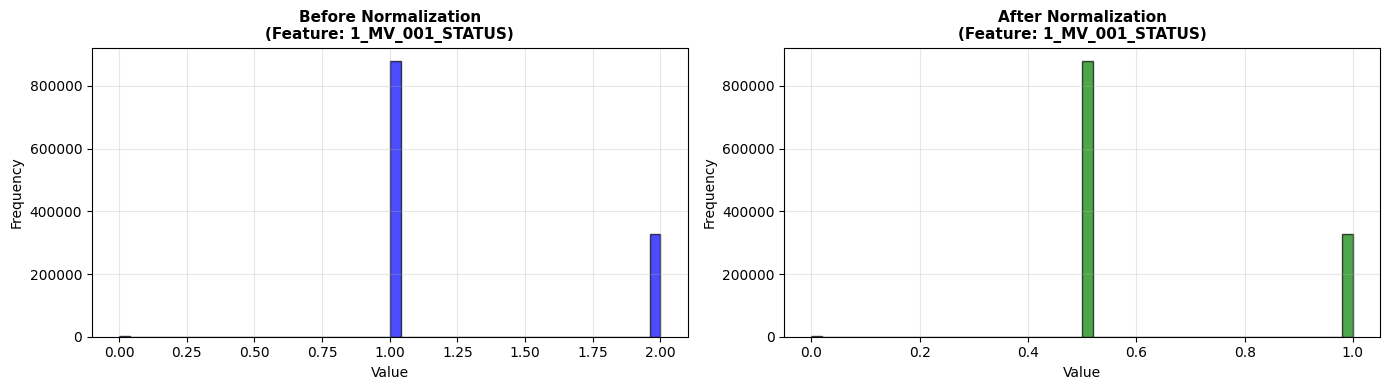


✓ Normalization complete!


In [4]:
print("="*70)
print("STEP 1: DATA NORMALIZATION (Min-Max Scaling)")
print("="*70)
print("\nFormula (1): X'' = (X' - X'_min) / (X'_max - X'_min)")

# Min-Max normalization to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_normalized = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_normalized = scaler.transform(X_test_raw).astype(np.float32)

print(f"\n{'Metric':<30} {'Training':<15} {'Testing'}")
print("-"*70)
print(f"{'Min value:':<30} {X_train_normalized.min():<15.6f} {X_test_normalized.min():<15.6f}")
print(f"{'Max value:':<30} {X_train_normalized.max():<15.6f} {X_test_normalized.max():<15.6f}")
print(f"{'Mean value:':<30} {X_train_normalized.mean():<15.6f} {X_test_normalized.mean():<15.6f}")
print(f"{'Std deviation:':<30} {X_train_normalized.std():<15.6f} {X_test_normalized.std():<15.6f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sample_feature = 0
axes[0].hist(X_train_raw[:, sample_feature], bins=50, alpha=0.7, 
            color='blue', edgecolor='black')
axes[0].set_title(f'Before Normalization\n(Feature: {feature_columns[sample_feature]})', 
                 fontsize=11, fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(X_train_normalized[:, sample_feature], bins=50, alpha=0.7, 
            color='green', edgecolor='black')
axes[1].set_title(f'After Normalization\n(Feature: {feature_columns[sample_feature]})', 
                 fontsize=11, fontweight='bold')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Normalization complete!")

STEP 2: SEQUENTIAL BILATERAL FILTERING (Denoising)

Formulas (2)-(7): Remove noise while preserving edges

FILTERING TRAINING DATA

Filter Configuration:
  Window size (ksize):     6
  Spatial sigma (δ₁):      1.0
  Value sigma (δ₂):        0.1
  Padding size:            31
  Processing 1,209,601 samples × 84 features...
  Progress: 100.00% - Complete!    

FILTERING TESTING DATA

Filter Configuration:
  Window size (ksize):     6
  Spatial sigma (δ₁):      1.0
  Value sigma (δ₂):        0.1
  Padding size:            31
  Processing 172,801 samples × 84 features...
  Progress: 100.00% - Complete!    


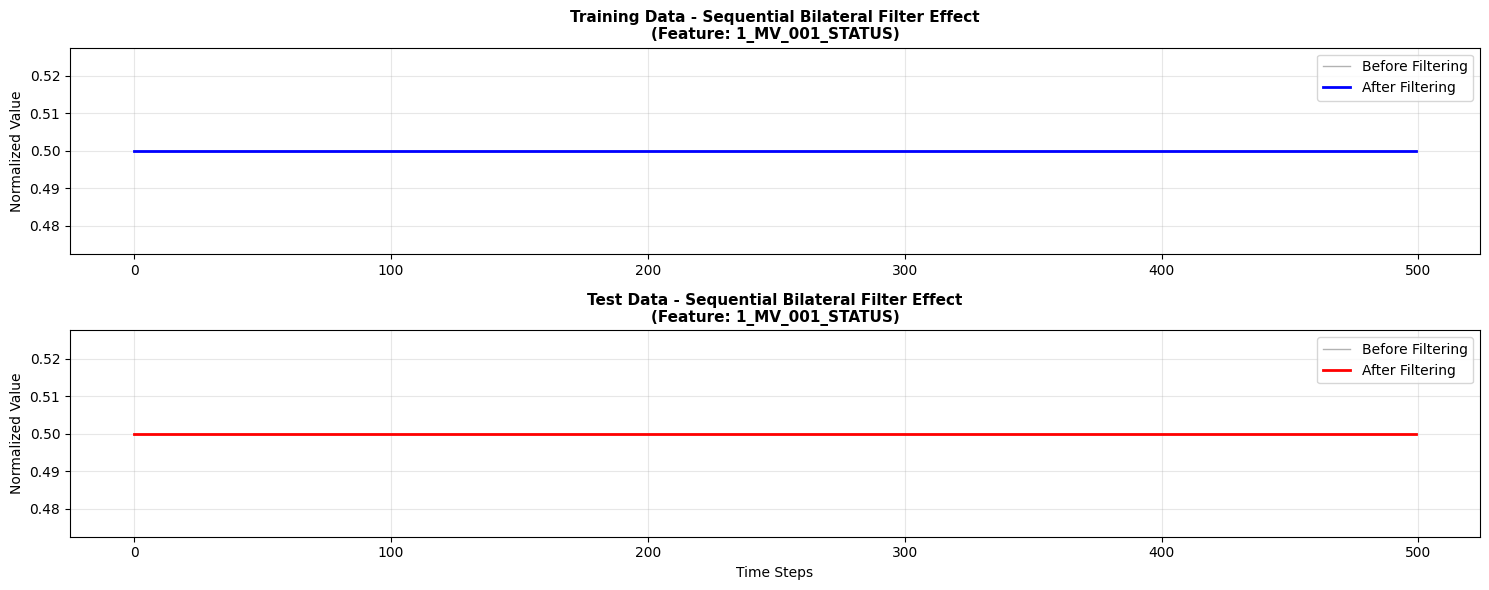


✓ Sequential bilateral filtering complete!


In [5]:
print("="*70)
print("STEP 2: SEQUENTIAL BILATERAL FILTERING (Denoising)")
print("="*70)
print("\nFormulas (2)-(7): Remove noise while preserving edges")

def sequential_bilateral_filter(data, ksize=6, sigma1=1.0, sigma2=0.1):
    """
    Sequential bilateral filter for time series denoising
    
    Args:
        data: Input data (samples x features)
        ksize: Filter window size (paper: 6)
        sigma1: Spatial domain std (δ₁)
        sigma2: Value domain std (δ₂)
    """
    filtered_data = np.copy(data)
    n_samples, n_features = data.shape
    
    # Padding: replicate first sample
    padding_size = 2 ** (ksize - 1) - 1
    padded_data = np.vstack([np.tile(data[0], (padding_size, 1)), data])
    
    # Distance array for spatial kernel
    distances = np.array([2**(ksize-1-i) - 1 for i in range(ksize)])
    
    print(f"\nFilter Configuration:")
    print(f"  Window size (ksize):     {ksize}")
    print(f"  Spatial sigma (δ₁):      {sigma1}")
    print(f"  Value sigma (δ₂):        {sigma2}")
    print(f"  Padding size:            {padding_size}")
    print(f"  Processing {n_samples:,} samples × {n_features} features...")
    
    # Pre-compute spatial kernel (Formula 2-3)
    spatial_diff = (distances - distances[-1]) ** 2
    wd = np.exp(-spatial_diff / (2 * sigma1 ** 2))
    WD = wd / np.sum(wd)
    
    # Process in batches
    batch_size = 10000
    for batch_start in range(0, n_samples, batch_size):
        batch_end = min(batch_start + batch_size, n_samples)
        
        for t in range(batch_start, batch_end):
            window_indices = [t + padding_size - d for d in distances]
            window_data = padded_data[window_indices]
            
            for j in range(n_features):
                window_values = window_data[:, j]
                current_value = data[t, j]
                
                # Value domain kernel (Formula 4-5)
                value_diff = (window_values - current_value) ** 2
                wr = np.exp(-value_diff / (2 * sigma2 ** 2))
                WR = wr / np.sum(wr)
                
                # Combined weight (Formula 6)
                W = WD * WR
                W = W / np.sum(W)
                
                # Filtered value (Formula 7)
                filtered_data[t, j] = np.sum(window_values * W)
        
        progress = (batch_end / n_samples) * 100
        print(f"  Progress: {progress:>6.2f}%", end='\r')
    
    print(f"  Progress: 100.00% - Complete!    ")
    return filtered_data

print("\n" + "="*70)
print("FILTERING TRAINING DATA")
print("="*70)
X_train_filtered = sequential_bilateral_filter(X_train_normalized, ksize=6)

print("\n" + "="*70)
print("FILTERING TESTING DATA")
print("="*70)
X_test_filtered = sequential_bilateral_filter(X_test_normalized, ksize=6)

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 6))

viz_range = slice(0, 500)
sample_feature = 0

axes[0].plot(X_train_normalized[viz_range, sample_feature], 
            label='Before Filtering', alpha=0.6, linewidth=1, color='gray')
axes[0].plot(X_train_filtered[viz_range, sample_feature], 
            label='After Filtering', linewidth=2, color='blue')
axes[0].set_title(f'Training Data - Sequential Bilateral Filter Effect\n(Feature: {feature_columns[sample_feature]})', 
                 fontsize=11, fontweight='bold')
axes[0].set_ylabel('Normalized Value')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(X_test_normalized[viz_range, sample_feature], 
            label='Before Filtering', alpha=0.6, linewidth=1, color='gray')
axes[1].plot(X_test_filtered[viz_range, sample_feature], 
            label='After Filtering', linewidth=2, color='red')
axes[1].set_title(f'Test Data - Sequential Bilateral Filter Effect\n(Feature: {feature_columns[sample_feature]})', 
                 fontsize=11, fontweight='bold')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Normalized Value')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Sequential bilateral filtering complete!")

STEP 3: DOWN-SAMPLING

Paper Section 3.2.3: 'Data is taken every 5s'

Dataset              Before               After                Reduction
--------------------------------------------------------------------------------
Training:            (1209601, 84)        (241921, 84)         80.0%
Testing:             (172801, 84)         (34561, 84)          80.0%


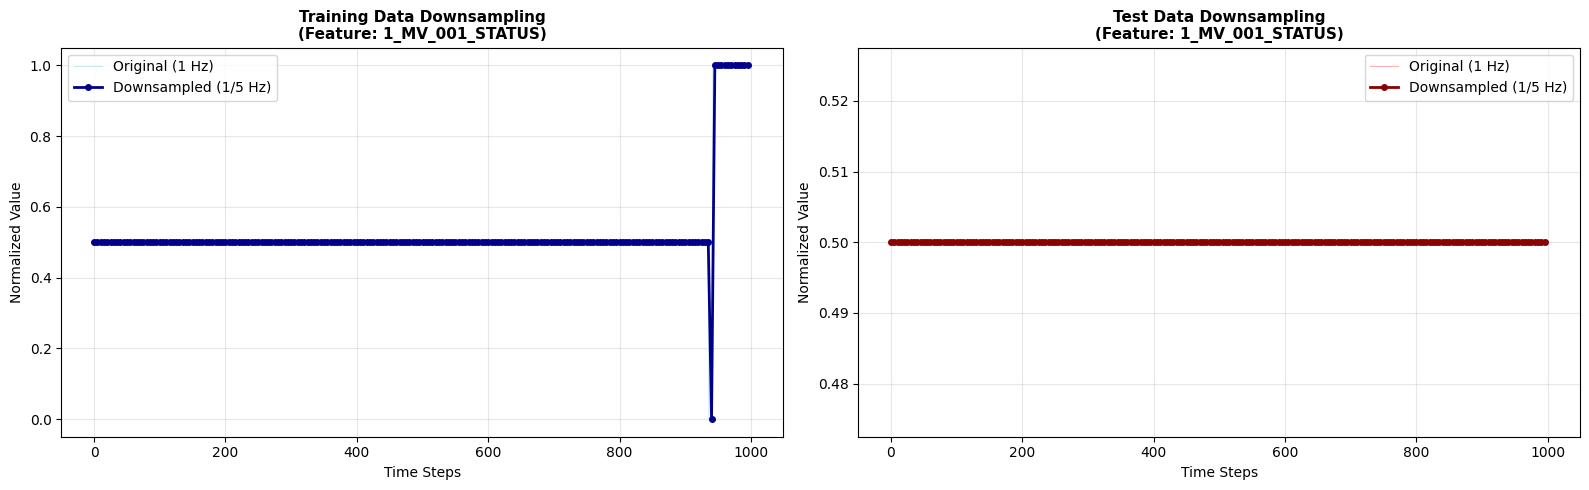


✓ Down-sampling complete!


In [6]:
print("="*70)
print("STEP 3: DOWN-SAMPLING")
print("="*70)
print("\nPaper Section 3.2.3: 'Data is taken every 5s'")

# Downsample: every 5th sample
downsample_rate = 5
X_train_downsampled = X_train_filtered[::downsample_rate].copy()
X_test_downsampled = X_test_filtered[::downsample_rate].copy()

print(f"\n{'Dataset':<20} {'Before':<20} {'After':<20} {'Reduction'}")
print("-"*80)
print(f"{'Training:':<20} {str(X_train_filtered.shape):<20} "
      f"{str(X_train_downsampled.shape):<20} "
      f"{(1-X_train_downsampled.shape[0]/X_train_filtered.shape[0])*100:.1f}%")
print(f"{'Testing:':<20} {str(X_test_filtered.shape):<20} "
      f"{str(X_test_downsampled.shape):<20} "
      f"{(1-X_test_downsampled.shape[0]/X_test_filtered.shape[0])*100:.1f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

viz_range = slice(0, 1000)
sample_feature = 0

# Training data
axes[0].plot(X_train_filtered[viz_range, sample_feature], 
            label='Original (1 Hz)', alpha=0.6, linewidth=0.8, color='lightblue')
axes[0].plot(np.arange(0, 1000, downsample_rate), 
            X_train_downsampled[viz_range.start//downsample_rate:viz_range.stop//downsample_rate, sample_feature], 
            'o-', label=f'Downsampled (1/{downsample_rate} Hz)', 
            markersize=4, linewidth=2, color='darkblue')
axes[0].set_title(f'Training Data Downsampling\n(Feature: {feature_columns[sample_feature]})', 
                 fontsize=11, fontweight='bold')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Normalized Value')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Test data
axes[1].plot(X_test_filtered[viz_range, sample_feature], 
            label='Original (1 Hz)', alpha=0.6, linewidth=0.8, color='lightcoral')
axes[1].plot(np.arange(0, 1000, downsample_rate), 
            X_test_downsampled[viz_range.start//downsample_rate:viz_range.stop//downsample_rate, sample_feature], 
            'o-', label=f'Downsampled (1/{downsample_rate} Hz)', 
            markersize=4, linewidth=2, color='darkred')
axes[1].set_title(f'Test Data Downsampling\n(Feature: {feature_columns[sample_feature]})', 
                 fontsize=11, fontweight='bold')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Normalized Value')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Down-sampling complete!")

STEP 4: DATA GROUPING (Table 3 - WADI)

Paper Table 3: WADI has 4 groups based on process connectivity
  Group 1: (P3, P1)   - Return water + Primary grid
  Group 2: (P1, P2A)  - Primary + Secondary A
  Group 3: (P2A, P2B) - Secondary A + Secondary B
  Group 4: (P2B, P3)  - Secondary B + Return water

GROUP CONFIGURATION

Group        Features   Stages                    Sample Features
------------------------------------------------------------------------------------------
Group_1      14         P3, P1                    1_MV_001_STATUS, 1_FIT_001_PV, 1_AIT_001_PV...
Group_2      17         P1, P2A                   1_MV_001_STATUS, 1_FIT_001_PV, 1_AIT_001_PV...
Group_3      3          P2A, P2B                  2A_AIT_001_PV, 2A_AIT_003_PV, 2A_AIT_004_PV
Group_4      67         P2B, P3                   2_LT_002_PV, 2_MCV_101_CO, 2_MCV_201_CO...


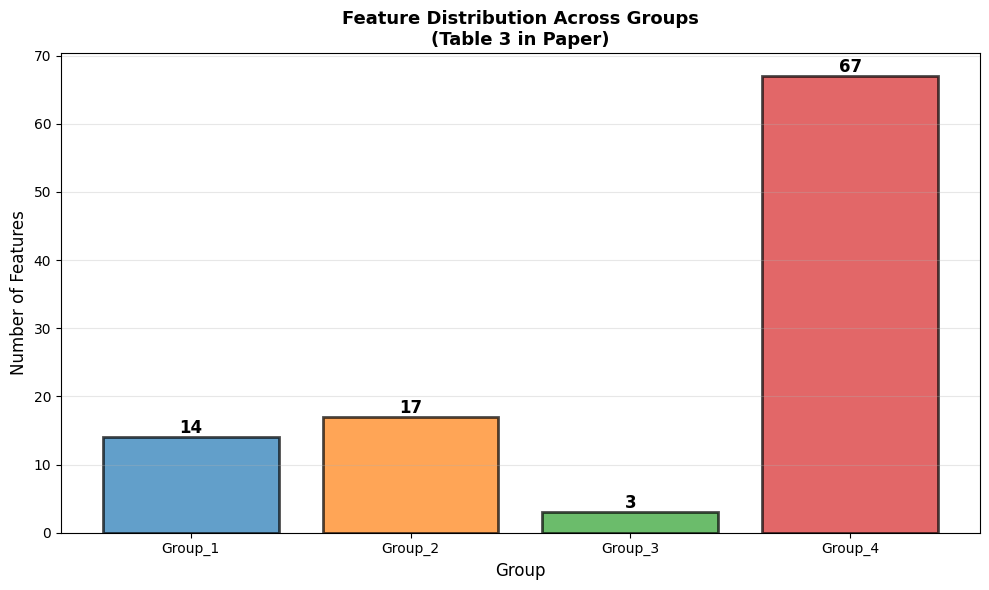


Total unique features: 84
Note: Features may appear in multiple groups (process connectivity)

✓ Data grouping complete!


In [7]:
print("="*70)
print("STEP 4: DATA GROUPING (Table 3 - WADI)")
print("="*70)
print("\nPaper Table 3: WADI has 4 groups based on process connectivity")
print("  Group 1: (P3, P1)   - Return water + Primary grid")
print("  Group 2: (P1, P2A)  - Primary + Secondary A")
print("  Group 3: (P2A, P2B) - Secondary A + Secondary B")
print("  Group 4: (P2B, P3)  - Secondary B + Return water")

# Initialize groups
groups = {
    'Group_1': [],  # P3 (3_) and P1 (1_)
    'Group_2': [],  # P1 (1_) and P2A (2A_)
    'Group_3': [],  # P2A (2A_) and P2B (2B_)
    'Group_4': []   # P2B (2B_), P2 (2_), and P3 (3_)
}

# Assign features to groups based on prefixes
for idx, col in enumerate(feature_columns):
    # Group 1: P3 (3_) and P1 (1_)
    if col.startswith('3_') or col.startswith('1_'):
        groups['Group_1'].append(idx)
    
    # Group 2: P1 (1_) and P2A (2A_)
    if col.startswith('1_') or col.startswith('2A_'):
        groups['Group_2'].append(idx)
    
    # Group 3: P2A (2A_) and P2B (2B_)
    if col.startswith('2A_') or col.startswith('2B_'):
        groups['Group_3'].append(idx)
    
    # Group 4: P2B (2B_), P2 (2_), and P3 (3_)
    if col.startswith('2B_') or col.startswith('2_') or col.startswith('3_'):
        groups['Group_4'].append(idx)

# Display grouping information
print(f"\n{'='*70}")
print("GROUP CONFIGURATION")
print(f"{'='*70}")
print(f"\n{'Group':<12} {'Features':<10} {'Stages':<25} {'Sample Features'}")
print("-"*90)

stage_mapping = {
    'Group_1': 'P3, P1',
    'Group_2': 'P1, P2A',
    'Group_3': 'P2A, P2B',
    'Group_4': 'P2B, P3'
}

for group_name, indices in groups.items():
    sample_features = [feature_columns[i] for i in indices[:3]]
    sample_str = ', '.join(sample_features)
    if len(indices) > 3:
        sample_str += '...'
    print(f"{group_name:<12} {len(indices):<10} {stage_mapping[group_name]:<25} {sample_str}")

# Visualize group sizes
plt.figure(figsize=(10, 6))
group_names = list(groups.keys())
group_sizes = [len(groups[g]) for g in group_names]

bars = plt.bar(group_names, group_sizes, 
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], 
              alpha=0.7, edgecolor='black', linewidth=2)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.title('Feature Distribution Across Groups\n(Table 3 in Paper)', 
         fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nTotal unique features: {len(feature_columns)}")
print("Note: Features may appear in multiple groups (process connectivity)")
print("\n✓ Data grouping complete!")

In [8]:
print("="*70)
print("TRAIN-VALIDATION SPLIT")
print("="*70)
print("\nPaper: '80% training, 20% validation'")
print("Paper: 'Remove first 30,000 samples (transition period)'")

# Split: 80% train, 20% validation
split_idx = int(0.8 * len(X_train_downsampled))
X_train_split = X_train_downsampled[:split_idx].copy()
X_val_split = X_train_downsampled[split_idx:].copy()

print(f"\nInitial split:")
print(f"  Training:   {len(X_train_split):>10,} samples ({len(X_train_split)/len(X_train_downsampled)*100:.1f}%)")
print(f"  Validation: {len(X_val_split):>10,} samples ({len(X_val_split)/len(X_train_downsampled)*100:.1f}%)")

# Remove first 30,000 samples (after downsampling: 30000/5 = 6000)
samples_to_remove = 6000

if len(X_train_split) > samples_to_remove:
    print(f"\nRemoving first {samples_to_remove:,} samples (transition from empty to stable state)...")
    X_train_split = X_train_split[samples_to_remove:].copy()
    print(f"  Remaining training samples: {len(X_train_split):,}")

# Final summary
print(f"\n{'='*70}")
print("FINAL DATA SPLIT")
print(f"{'='*70}")
print(f"\n{'Dataset':<20} {'Samples':<15} {'Features':<10} {'Memory (MB)'}")
print("-"*70)
print(f"{'Training:':<20} {len(X_train_split):>14,} {X_train_split.shape[1]:>9,} "
      f"{X_train_split.nbytes/(1024**2):>12.2f}")
print(f"{'Validation:':<20} {len(X_val_split):>14,} {X_val_split.shape[1]:>9,} "
      f"{X_val_split.nbytes/(1024**2):>12.2f}")
print(f"{'Testing:':<20} {len(X_test_downsampled):>14,} {X_test_downsampled.shape[1]:>9,} "
      f"{X_test_downsampled.nbytes/(1024**2):>12.2f}")

print("\n✓ Data split complete!")

TRAIN-VALIDATION SPLIT

Paper: '80% training, 20% validation'
Paper: 'Remove first 30,000 samples (transition period)'

Initial split:
  Training:      193,536 samples (80.0%)
  Validation:     48,385 samples (20.0%)

Removing first 6,000 samples (transition from empty to stable state)...
  Remaining training samples: 187,536

FINAL DATA SPLIT

Dataset              Samples         Features   Memory (MB)
----------------------------------------------------------------------
Training:                   187,536        84        60.09
Validation:                  48,385        84        15.50
Testing:                     34,561        84        11.07

✓ Data split complete!


In [12]:
print("="*70)
print("DEFINING TIME SERIES DATASET CLASS")
print("="*70)

class TimeSeriesDataset(Dataset):
    """
    Time series dataset for sliding window prediction
    Creates (historical, future) sequence pairs
    """
    def __init__(self, data, L1=96, L2=12, mask_rate=0.7, patch_size=4):
        """
        Args:
            data: Input time series (numpy array)
            L1: Historical sequence length (Table 2: 96)
            L2: Future sequence length (Table 2: 12)
            mask_rate: Random mask rate (Table 2: 0.7)
            patch_size: Patch size for masking
        """
        self.data = torch.FloatTensor(data)
        self.L1 = L1
        self.L2 = L2
        self.mask_rate = mask_rate
        self.patch_size = patch_size
        self.n_samples = len(data) - L1 - L2 + 1
        
    def __len__(self):
        return max(0, self.n_samples)
    
    def __getitem__(self, idx):
        # Extract historical and future sequences
        hist_seq = self.data[idx:idx+self.L1]
        future_seq = self.data[idx+self.L1:idx+self.L1+self.L2]
        
        return hist_seq, future_seq

print("\nDataset Configuration:")
print("  • Creates sliding windows over time series")
print("  • Historical window (L1): Input to prediction model")
print("  • Future window (L2): Target for prediction")
print("  • Random patch masking during training")

print("\n✓ TimeSeriesDataset class defined!")

DEFINING TIME SERIES DATASET CLASS

Dataset Configuration:
  • Creates sliding windows over time series
  • Historical window (L1): Input to prediction model
  • Future window (L2): Target for prediction
  • Random patch masking during training

✓ TimeSeriesDataset class defined!


In [13]:
print("="*70)
print("DEFINING MLP-BASED PREDICTION MODEL")
print("="*70)
print("\nBased on Figure 3 (Network Architecture) and Figure 4 (MLP Block)")

class MLPBlock(nn.Module):
    """
    Basic MLP Block (Figure 4 in paper)
    Architecture: Linear → ReLU → Linear → Dropout → LayerNorm + Residual
    """
    def __init__(self, input_dim, hidden_dim, dropout=0.2):
        super(MLPBlock, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, input_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(input_dim)
        
    def forward(self, x):
        residual = x
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.dropout(x)
        x = self.layer_norm(x + residual)  # Residual connection
        return x


class PredictionModel(nn.Module):
    """
    Distributed MLP-based Prediction Model (Section 3.3)
    Uses random patch masking to reduce redundancy
    """
    def __init__(self, n_features, L1=96, L2=12, hidden_dim=1024, 
                 n_blocks=3, dropout=0.2, mask_rate=0.7, patch_size=4):
        """
        Args:
            n_features: Number of input features
            L1: Historical sequence length (Table 2: 96)
            L2: Future sequence length (Table 2: 12)
            hidden_dim: Hidden dimension (Table 2: 1024 for WADI)
            n_blocks: Number of MLP blocks (Table 2: 3 for WADI)
            dropout: Dropout rate (Table 2: 0.2)
            mask_rate: Random mask rate (Table 2: 0.7)
            patch_size: Size of patches
        """
        super(PredictionModel, self).__init__()
        self.L1 = L1
        self.L2 = L2
        self.n_features = n_features
        self.mask_rate = mask_rate
        self.patch_size = patch_size
        self.n_patches = L1 // patch_size
        
        # Input projection: patches → hidden dimension
        self.input_proj = nn.Linear(n_features * patch_size, hidden_dim)
        
        # Stack of MLP blocks (Figure 3)
        self.mlp_blocks = nn.ModuleList([
            MLPBlock(hidden_dim, hidden_dim * 2, dropout) 
            for _ in range(n_blocks)
        ])
        
        # Output projection: hidden → prediction
        self.output_proj = nn.Linear(hidden_dim, n_features * L2)
        
        # Learnable mask tokens (Section 3.3.2)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, n_features * patch_size))
        
    def create_patches(self, x):
        """
        Split time series into non-overlapping patches
        Input:  (batch, L1, n_features)
        Output: (batch, n_patches, patch_size * n_features)
        """
        batch_size = x.shape[0]
        x = x.reshape(batch_size, self.n_patches, self.patch_size * self.n_features)
        return x
    
    def apply_random_mask(self, x, training=True):
        """
        Apply random patch masking (Section 3.3.2)
        Reduces redundancy in industrial control data
        """
        if not training:
            return x
            
        batch_size, n_patches, patch_dim = x.shape
        
        # Random mask: keep patch if random > mask_rate
        mask = torch.rand(batch_size, n_patches, 1, device=x.device) > self.mask_rate
        masked_x = x * mask + self.mask_token * (~mask)
        
        return masked_x
    
    def forward(self, x, training=True):
        """
        Forward pass
        Input:  (batch, L1, n_features)
        Output: (batch, L2, n_features)
        """
        batch_size = x.shape[0]
        
        # Step 1: Create patches
        x = self.create_patches(x)
        
        # Step 2: Apply random masking (training only)
        x = self.apply_random_mask(x, training)
        
        # Step 3: Project to hidden dimension
        x = self.input_proj(x)
        
        # Step 4: Apply MLP blocks
        for block in self.mlp_blocks:
            x = block(x)
        
        # Step 5: Average pooling over patches
        x = x.mean(dim=1)
        
        # Step 6: Project to output
        x = self.output_proj(x)
        
        # Step 7: Reshape to (batch, L2, n_features)
        x = x.reshape(batch_size, self.L2, self.n_features)
        
        return x


print("\nModel Components:")
print("  ✓ MLPBlock: Basic building block with residual connections")
print("  ✓ PredictionModel: Full architecture with:")
print("    • Patch creation")
print("    • Random masking (reduces redundancy)")
print("    • MLP blocks stack")
print("    • Output projection")

print("\n✓ Model architecture defined!")

DEFINING MLP-BASED PREDICTION MODEL

Based on Figure 3 (Network Architecture) and Figure 4 (MLP Block)

Model Components:
  ✓ MLPBlock: Basic building block with residual connections
  ✓ PredictionModel: Full architecture with:
    • Patch creation
    • Random masking (reduces redundancy)
    • MLP blocks stack
    • Output projection

✓ Model architecture defined!


In [14]:
print("="*70)
print("DEFINING TRAINING FUNCTION (Algorithm 1)")
print("="*70)

def train_model(model, train_loader, val_loader, n_epochs=500, lr=0.0005, 
                patience=100, device='cuda'):
    """
    Train the prediction model (Algorithm 1 in paper)
    
    Args:
        model: Prediction model
        train_loader: Training data loader
        val_loader: Validation data loader
        n_epochs: Number of epochs (Table 2: 500, we use 100)
        lr: Learning rate (Table 2: 0.0005)
        patience: Early stopping patience (set to n_epochs to disable)
        device: 'cuda' or 'cpu'
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()  # Formula (8)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    
    print(f"\nTraining Configuration:")
    print(f"  Device:           {device}")
    print(f"  Epochs:           {n_epochs}")
    print(f"  Learning Rate:    {lr}")
    print(f"  Optimizer:        Adam")
    print(f"  Loss Function:    MSE (Formula 8)")
    print(f"  Early Stopping:   {'Disabled' if patience >= n_epochs else f'Enabled (patience={patience})'}")
    
    print(f"\n{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'Best':<10} {'Status'}")
    print("-"*70)
    
    for epoch in range(n_epochs):
        # === TRAINING PHASE ===
        model.train()
        train_loss = 0
        train_batches = 0
        
        for hist_seq, future_seq in train_loader:
            hist_seq = hist_seq.to(device)
            future_seq = future_seq.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass with random masking
            pred = model(hist_seq, training=True)
            
            # Calculate loss (Formula 8: MSE)
            loss = criterion(pred, future_seq)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_batches += 1
        
        train_loss /= train_batches
        train_losses.append(train_loss)
        
        # === VALIDATION PHASE ===
        model.eval()
        val_loss = 0
        val_batches = 0
        
        with torch.no_grad():
            for hist_seq, future_seq in val_loader:
                hist_seq = hist_seq.to(device)
                future_seq = future_seq.to(device)
                
                # Forward pass without masking
                pred = model(hist_seq, training=False)
                loss = criterion(pred, future_seq)
                
                val_loss += loss.item()
                val_batches += 1
        
        val_loss /= val_batches
        val_losses.append(val_loss)
        
        # Check for improvement
        status = ""
        is_best = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
            is_best = "✓"
            status = "Best"
        else:
            patience_counter += 1
            if patience_counter >= patience:
                status = "Early Stop"
        
        # Print progress (every 5 epochs or important events)
        if (epoch + 1) % 5 == 0 or status != "":
            print(f"{epoch+1:<8} {train_loss:<15.6f} {val_loss:<15.6f} {is_best:<10} {status}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            print(f"Best validation loss: {best_val_loss:.6f}")
            break
    
    # Load best model
    model.load_state_dict(torch.load('best_model.pth'))
    
    print(f"\n{'='*70}")
    print("TRAINING COMPLETED")
    print(f"{'='*70}")
    print(f"  Total epochs:       {len(train_losses)}")
    print(f"  Final train loss:   {train_losses[-1]:.6f}")
    print(f"  Final val loss:     {val_losses[-1]:.6f}")
    print(f"  Best val loss:      {best_val_loss:.6f}")
    
    return model, train_losses, val_losses

print("\n✓ Training function defined!")

DEFINING TRAINING FUNCTION (Algorithm 1)

✓ Training function defined!


TRAINING DISTRIBUTED MODELS FOR EACH GROUP

Hyperparameters (from Table 2 - WADI):
  L1 (Historical window):      96
  L2 (Future window):          12
  Hidden dimension:            1024
  MLP blocks:                  3
  Dropout:                     0.2
  Mask rate:                   0.7
  Batch size:                  512
  Training epochs:             500
  Learning rate:               0.0005
  Early stopping patience:     50
  Device:                      cuda

TRAINING GROUP_1
Features: 14
Stages: P3, P1

Data shapes:
  Training:   (187536, 14)
  Validation: (48385, 14)

Dataset sizes:
  Training samples:   187,429
  Validation samples: 48,278
  Training batches:   367
  Validation batches: 95

Model parameters:
  Total:      12,828,896
  Trainable:  12,828,896

Training Configuration:
  Device:           cuda
  Epochs:           500
  Learning Rate:    0.0005
  Optimizer:        Adam
  Loss Function:    MSE (Formula 8)
  Early Stopping:   Enabled (patience=50)

Epoch    Train Loss

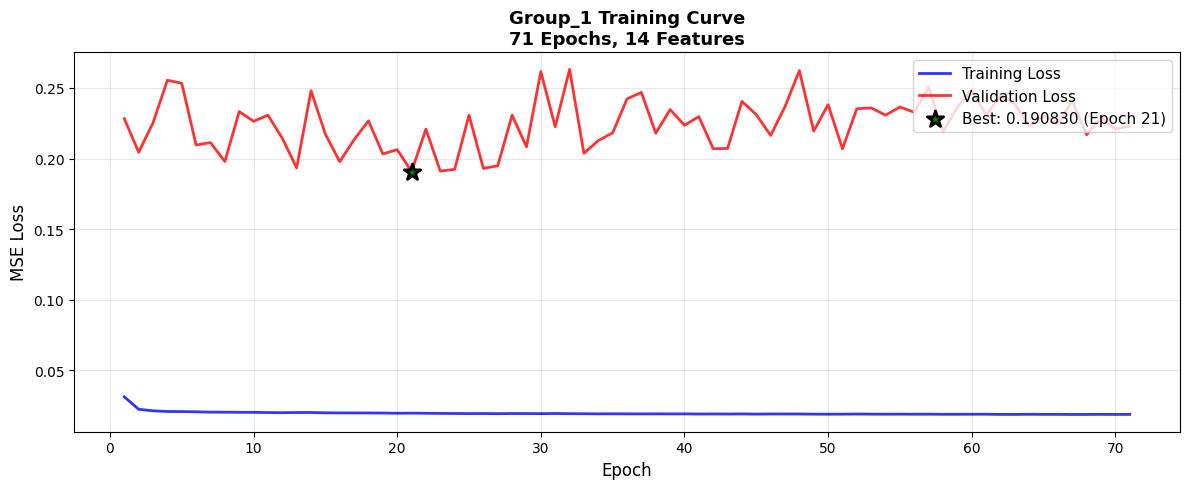


✓ Group_1 training complete!
  Epochs:          71
  Final train:     0.018921
  Final val:       0.222952
  Best val:        0.190830
  ⚠ Early stopped at epoch 71/500

TRAINING GROUP_2
Features: 17
Stages: P1, P2A

Data shapes:
  Training:   (187536, 17)
  Validation: (48385, 17)

Dataset sizes:
  Training samples:   187,429
  Validation samples: 48,278
  Training batches:   367
  Validation batches: 95

Model parameters:
  Total:      12,878,096
  Trainable:  12,878,096

Training Configuration:
  Device:           cuda
  Epochs:           500
  Learning Rate:    0.0005
  Optimizer:        Adam
  Loss Function:    MSE (Formula 8)
  Early Stopping:   Enabled (patience=50)

Epoch    Train Loss      Val Loss        Best       Status
----------------------------------------------------------------------
1        0.027279        0.206381        ✓          Best
5        0.017184        0.245999                   
10       0.016659        0.330606                   
15       0.016205      

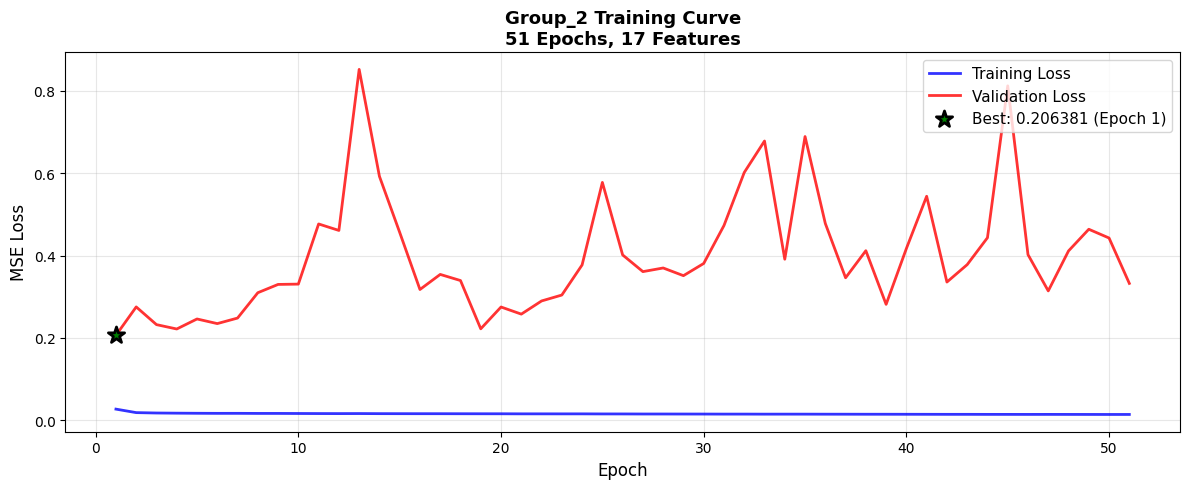


✓ Group_2 training complete!
  Epochs:          51
  Final train:     0.014333
  Final val:       0.332309
  Best val:        0.206381
  ⚠ Early stopped at epoch 51/500

TRAINING GROUP_3
Features: 3
Stages: P2A, P2B

Data shapes:
  Training:   (187536, 3)
  Validation: (48385, 3)

Dataset sizes:
  Training samples:   187,429
  Validation samples: 48,278
  Training batches:   367
  Validation batches: 95

Model parameters:
  Total:      12,648,496
  Trainable:  12,648,496

Training Configuration:
  Device:           cuda
  Epochs:           500
  Learning Rate:    0.0005
  Optimizer:        Adam
  Loss Function:    MSE (Formula 8)
  Early Stopping:   Enabled (patience=50)

Epoch    Train Loss      Val Loss        Best       Status
----------------------------------------------------------------------
1        0.018792        0.123522        ✓          Best
2        0.002312        0.116783        ✓          Best
3        0.001955        0.101856        ✓          Best
5        0.001703

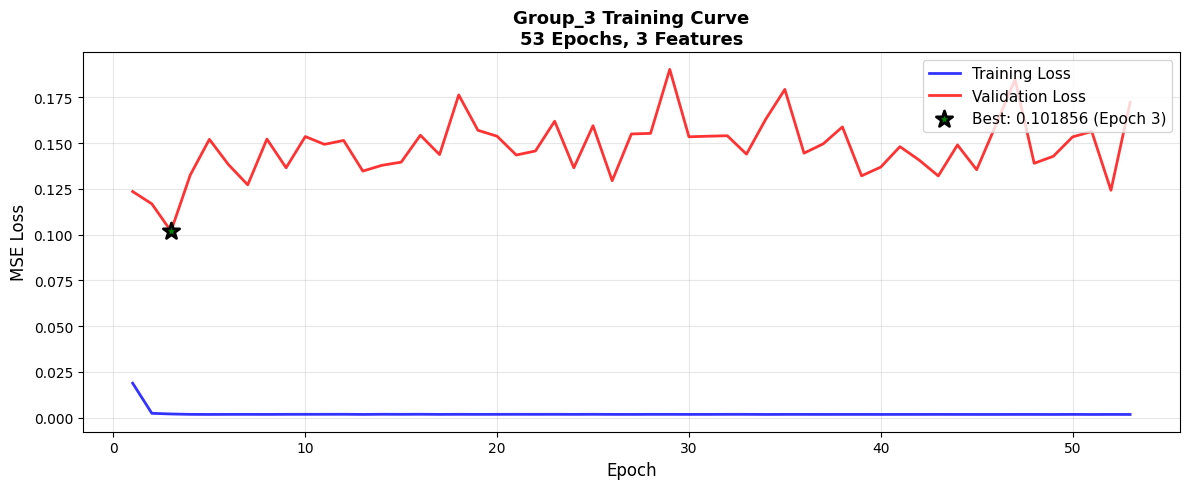


✓ Group_3 training complete!
  Epochs:          53
  Final train:     0.001690
  Final val:       0.172253
  Best val:        0.101856
  ⚠ Early stopped at epoch 53/500

TRAINING GROUP_4
Features: 67
Stages: P2B, P3

Data shapes:
  Training:   (187536, 67)
  Validation: (48385, 67)

Dataset sizes:
  Training samples:   187,429
  Validation samples: 48,278
  Training batches:   367
  Validation batches: 95

Model parameters:
  Total:      13,698,096
  Trainable:  13,698,096

Training Configuration:
  Device:           cuda
  Epochs:           500
  Learning Rate:    0.0005
  Optimizer:        Adam
  Loss Function:    MSE (Formula 8)
  Early Stopping:   Enabled (patience=50)

Epoch    Train Loss      Val Loss        Best       Status
----------------------------------------------------------------------
1        0.015063        0.121545        ✓          Best
2        0.008131        0.116698        ✓          Best
5        0.007249        0.124960                   
10       0.006795  

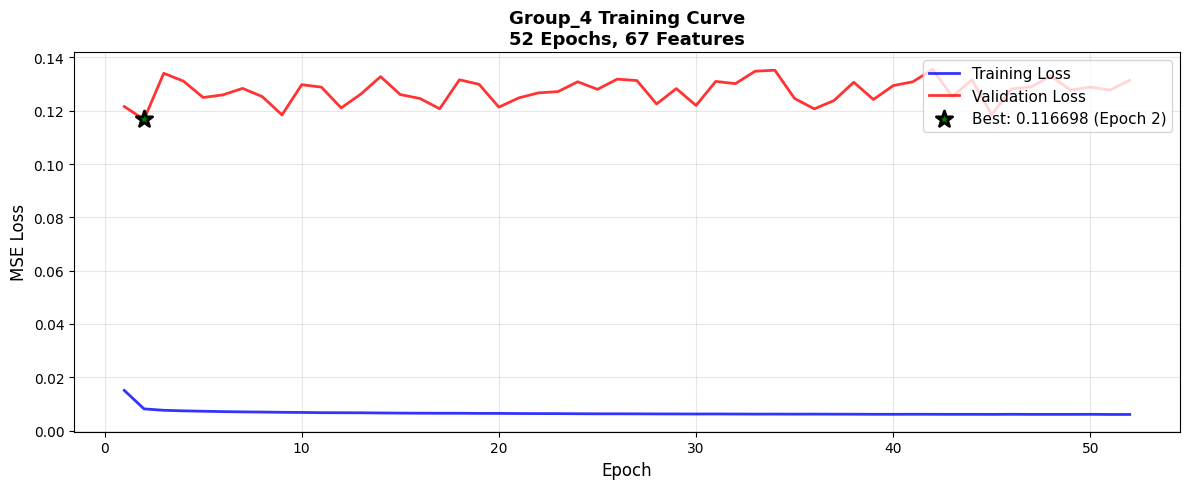


✓ Group_4 training complete!
  Epochs:          52
  Final train:     0.006040
  Final val:       0.131439
  Best val:        0.116698
  ⚠ Early stopped at epoch 52/500

ALL MODELS TRAINED SUCCESSFULLY!

Group        Features   Epochs     Best Val Loss
----------------------------------------------------------------------
Group_1      14         71         0.190830
Group_2      17         51         0.206381
Group_3      3          53         0.101856
Group_4      67         52         0.116698

✓ Training phase complete!


In [15]:
print("="*70)
print("TRAINING DISTRIBUTED MODELS FOR EACH GROUP")
print("="*70)

# Hyperparameters from Table 2 (WADI configuration)
L1 = 96           # Historical sequence length
L2 = 12           # Future sequence length
hidden_dim = 1024 # Hidden dimension
n_blocks = 3      # Number of MLP blocks
dropout = 0.2     # Dropout rate
mask_rate = 0.7   # Mask rate
batch_size = 512  # Batch size
n_epochs = 500    # Training epochs (as per paper)  # ✓ CHANGED: 100 → 500
lr = 0.0005       # Learning rate
patience = 50     # ✓ ADDED: Early stopping patience

print(f"\nHyperparameters (from Table 2 - WADI):")
print(f"  L1 (Historical window):      {L1}")
print(f"  L2 (Future window):          {L2}")
print(f"  Hidden dimension:            {hidden_dim}")
print(f"  MLP blocks:                  {n_blocks}")
print(f"  Dropout:                     {dropout}")
print(f"  Mask rate:                   {mask_rate}")
print(f"  Batch size:                  {batch_size}")
print(f"  Training epochs:             {n_epochs}")
print(f"  Learning rate:               {lr}")
print(f"  Early stopping patience:     {patience}")  # ✓ ADDED: Display patience
print(f"  Device:                      {device}")

# Storage for models and results
group_models = {}
group_results = {}

# Train model for each group
for group_name, feature_indices in groups.items():
    if len(feature_indices) == 0:
        print(f"\n⚠ Skipping {group_name} (no features)")
        continue
    
    print(f"\n{'='*70}")
    print(f"TRAINING {group_name.upper()}")
    print(f"{'='*70}")
    print(f"Features: {len(feature_indices)}")
    print(f"Stages: {stage_mapping[group_name]}")
    
    # Extract group-specific features
    X_train_group = X_train_split[:, feature_indices]
    X_val_group = X_val_split[:, feature_indices]
    
    print(f"\nData shapes:")
    print(f"  Training:   {X_train_group.shape}")
    print(f"  Validation: {X_val_group.shape}")
    
    # Create datasets
    train_dataset = TimeSeriesDataset(X_train_group, L1=L1, L2=L2, mask_rate=mask_rate)
    val_dataset = TimeSeriesDataset(X_val_group, L1=L1, L2=L2, mask_rate=mask_rate)
    
    print(f"\nDataset sizes:")
    print(f"  Training samples:   {len(train_dataset):,}")
    print(f"  Validation samples: {len(val_dataset):,}")
    
    if len(train_dataset) == 0 or len(val_dataset) == 0:
        print(f"⚠ Insufficient data for {group_name}, skipping...")
        continue
    
    # Create dataloaders (pin_memory for faster CUDA transfer)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        pin_memory=(device.type == 'cuda'),
        num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        pin_memory=(device.type == 'cuda'),
        num_workers=0
    )
    
    print(f"  Training batches:   {len(train_loader)}")
    print(f"  Validation batches: {len(val_loader)}")
    
    # Create model
    model = PredictionModel(
        n_features=len(feature_indices),
        L1=L1,
        L2=L2,
        hidden_dim=hidden_dim,
        n_blocks=n_blocks,
        dropout=dropout,
        mask_rate=mask_rate
    )
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters:")
    print(f"  Total:      {total_params:>10,}")
    print(f"  Trainable:  {trainable_params:>10,}")
    
    # Train model
    model, train_losses, val_losses = train_model(
        model, train_loader, val_loader, 
        n_epochs=n_epochs, lr=lr, patience=patience, device=device  # ✓ CHANGED: patience=n_epochs → patience=patience
    )
    
    # Store results
    group_models[group_name] = model
    group_results[group_name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'feature_indices': feature_indices
    }
    
    # Plot training curves
    plt.figure(figsize=(12, 5))
    epochs_range = range(1, len(train_losses) + 1)
    
    plt.plot(epochs_range, train_losses, 'b-', label='Training Loss', 
            linewidth=2, alpha=0.8)
    plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', 
            linewidth=2, alpha=0.8)
    
    # Mark best validation loss
    best_idx = np.argmin(val_losses)
    best_val_loss = val_losses[best_idx]
    plt.scatter(best_idx + 1, best_val_loss, color='green', s=150, 
               zorder=5, marker='*', edgecolors='black', linewidths=2,
               label=f'Best: {best_val_loss:.6f} (Epoch {best_idx + 1})')
    
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MSE Loss', fontsize=12)
    plt.title(f'{group_name} Training Curve\n{len(train_losses)} Epochs, {len(feature_indices)} Features', 
             fontsize=13, fontweight='bold')
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ {group_name} training complete!")
    print(f"  Epochs:          {len(train_losses)}")
    print(f"  Final train:     {train_losses[-1]:.6f}")
    print(f"  Final val:       {val_losses[-1]:.6f}")
    print(f"  Best val:        {best_val_loss:.6f}")
    
    # ✓ ADDED: Display early stopping information
    if len(train_losses) < n_epochs:
        print(f"  ⚠ Early stopped at epoch {len(train_losses)}/{n_epochs}")
    else:
        print(f"  ✓ Completed all {n_epochs} epochs")
    
    # Free CUDA memory
    if device.type == 'cuda':
        torch.cuda.empty_cache()

# Final summary
print(f"\n{'='*70}")
print("ALL MODELS TRAINED SUCCESSFULLY!")
print(f"{'='*70}")
print(f"\n{'Group':<12} {'Features':<10} {'Epochs':<10} {'Best Val Loss'}")
print("-"*70)
for group_name in group_models.keys():
    n_features = len(group_results[group_name]['feature_indices'])
    epochs = len(group_results[group_name]['val_losses'])
    best_loss = min(group_results[group_name]['val_losses'])
    print(f"{group_name:<12} {n_features:<10} {epochs:<10} {best_loss:.6f}")

print("\n✓ Training phase complete!")

In [17]:
print("="*70)
print("CALCULATING DETECTION THRESHOLDS (Formula 12)")
print("="*70)
print("\nUsing validation set to determine anomaly thresholds per feature")

def calculate_prediction_errors(model, data, feature_indices, L1, L2, gamma=3, device='cuda'):
    """
    Calculate prediction errors for threshold determination (Formula 9)
    
    Args:
        model: Trained prediction model
        data: Input data (validation set)
        feature_indices: Feature indices for this group
        L1: Historical window length
        L2: Future window length
        gamma: Error exponent (Table 2: 3 for WADI)
        device: 'cuda' or 'cpu'
    
    Returns:
        errors: Prediction errors (samples x features)
    """
    model.eval()
    errors = []
    
    # Extract group features
    group_data = data[:, feature_indices]
    n_samples = len(group_data) - L1 - L2 + 1
    
    print(f"  Processing {n_samples:,} validation samples...")
    
    with torch.no_grad():
        batch_size = 512
        for i in range(0, n_samples, batch_size):
            batch_end = min(i + batch_size, n_samples)
            batch_errors = []
            
            for j in range(i, batch_end):
                hist_seq = torch.FloatTensor(group_data[j:j+L1]).unsqueeze(0).to(device)
                future_seq = group_data[j+L1:j+L1+L2]
                
                pred = model(hist_seq, training=False).cpu().numpy()[0]
                
                # Formula 9: error_j = |X_j - X̂_j|^γ
                error = np.abs(future_seq[-1] - pred[-1]) ** gamma
                batch_errors.append(error)
            
            errors.extend(batch_errors)
            
            if (batch_end - i) >= batch_size:
                progress = batch_end / n_samples * 100
                print(f"    Progress: {progress:>6.2f}%", end='\r')
    
    print(f"    Progress: 100.00% - Complete!")
    return np.array(errors)


def exponential_weighted_average(errors, H=14):
    """
    Smooth errors using exponential weighted average (Formulas 10-11)
    
    Args:
        errors: Raw prediction errors (samples x features)
        H: Smoothing length (Table 2: 14 for WADI)
    
    Returns:
        smoothed: Smoothed errors
    """
    # Formula 10: β = 0.5^(1/H)
    beta = 0.5 ** (1.0 / H)
    
    n_samples, n_features = errors.shape
    smoothed = np.zeros_like(errors)
    
    # Formula 11: P_t^j = (1-β)·error_t^j + β·P_{t-1}^j
    for j in range(n_features):
        smoothed[0, j] = errors[0, j]
        for t in range(1, n_samples):
            smoothed[t, j] = (1 - beta) * errors[t, j] + beta * smoothed[t-1, j]
    
    return smoothed


# Parameters from Table 2
gamma = 3   # Error exponent
H = 14      # Smoothing length

print(f"\nThreshold Calculation Parameters (Table 2):")
print(f"  Gamma (γ):           {gamma}")
print(f"  H (smoothing):       {H}")
print(f"  Formula 12:          TH_j = a * Max_j + b")
print(f"  Coefficients:        a = 1.0, b = 0.0")

# Calculate thresholds for each group
group_thresholds = {}

for group_name, model in group_models.items():
    print(f"\n{'-'*70}")
    print(f"Processing {group_name}...")
    print(f"{'-'*70}")
    
    feature_indices = group_results[group_name]['feature_indices']
    
    # Step 1: Calculate prediction errors on validation set
    errors = calculate_prediction_errors(
        model, X_val_split, feature_indices, L1, L2, gamma, device
    )
    
    print(f"  Error statistics:")
    print(f"    Shape:       {errors.shape}")
    print(f"    Min:         {errors.min():.6f}")
    print(f"    Max:         {errors.max():.6f}")
    print(f"    Mean:        {errors.mean():.6f}")
    
    # Step 2: Apply exponential weighted average smoothing
    print(f"  Applying exponential weighted average (H={H})...")
    smoothed_errors = np.array([
        exponential_weighted_average(errors[:, j:j+1], H).flatten()
        for j in range(errors.shape[1])
    ])
    
    # Step 3: Calculate threshold per feature (Formula 12)
    # TH_j = a * Max_j + b
    a = 1.0
    b = 0.0
    max_errors = smoothed_errors.max(axis=1)
    thresholds = a * max_errors + b
    
    group_thresholds[group_name] = thresholds
    
    print(f"  ✓ Thresholds calculated for {len(thresholds)} features")
    print(f"    Min threshold:   {thresholds.min():.6f}")
    print(f"    Max threshold:   {thresholds.max():.6f}")
    print(f"    Mean threshold:  {thresholds.mean():.6f}")
    print(f"    Median threshold: {np.median(thresholds):.6f}")

print(f"\n{'='*70}")
print("✓ THRESHOLD CALCULATION COMPLETE")
print(f"{'='*70}")

# Summary table
print(f"\n{'Group':<12} {'Features':<10} {'Min Thresh':<15} {'Max Thresh':<15} {'Mean Thresh'}")
print("-"*80)
for group_name, thresholds in group_thresholds.items():
    n_features = len(thresholds)
    print(f"{group_name:<12} {n_features:<10} {thresholds.min():<15.6f} "
          f"{thresholds.max():<15.6f} {thresholds.mean():.6f}")

CALCULATING DETECTION THRESHOLDS (Formula 12)

Using validation set to determine anomaly thresholds per feature

Threshold Calculation Parameters (Table 2):
  Gamma (γ):           3
  H (smoothing):       14
  Formula 12:          TH_j = a * Max_j + b
  Coefficients:        a = 1.0, b = 0.0

----------------------------------------------------------------------
Processing Group_1...
----------------------------------------------------------------------
  Processing 48,278 validation samples...
    Progress: 100.00% - Complete!
  Error statistics:
    Shape:       (48278, 14)
    Min:         0.000000
    Max:         8.289397
    Mean:        0.192175
  Applying exponential weighted average (H=14)...
  ✓ Thresholds calculated for 14 features
    Min threshold:   0.000001
    Max threshold:   4.867548
    Mean threshold:  1.396207
    Median threshold: 0.055494

----------------------------------------------------------------------
Processing Group_2...
---------------------------------

In [18]:
print("="*70)
print("ANOMALY DETECTION ON TEST SET (Algorithm 2)")
print("="*70)

def detect_anomalies(model, data, feature_indices, thresholds, L1, L2, 
                     gamma=3, H=14, device='cuda'):
    """
    Detect anomalies in test data (Algorithm 2 in paper)
    
    Args:
        model: Trained prediction model
        data: Test data
        feature_indices: Feature indices for this group
        thresholds: Detection thresholds (one per feature)
        L1, L2: Window lengths
        gamma: Error exponent
        H: Smoothing length
        device: 'cuda' or 'cpu'
    
    Returns:
        anomaly_labels: Binary labels (0=normal, 1=anomaly) per timestep
        feature_anomalies: Binary per-feature anomaly indicators
        smoothed_errors: Smoothed prediction errors
    """
    model.eval()
    n_features = len(feature_indices)
    group_data = data[:, feature_indices]
    n_samples = len(group_data) - L1 - L2 + 1
    
    all_errors = []
    
    print(f"  Detecting anomalies in {n_samples:,} test samples...")
    
    with torch.no_grad():
        batch_size = 512
        for i in range(0, n_samples, batch_size):
            batch_end = min(i + batch_size, n_samples)
            batch_errors = []
            
            for j in range(i, batch_end):
                hist_seq = torch.FloatTensor(group_data[j:j+L1]).unsqueeze(0).to(device)
                future_seq = group_data[j+L1:j+L1+L2]
                
                pred = model(hist_seq, training=False).cpu().numpy()[0]
                
                # Formula 9: error_j = |X_j - X̂_j|^γ
                error = np.abs(future_seq[-1] - pred[-1]) ** gamma
                batch_errors.append(error)
            
            all_errors.extend(batch_errors)
            
            if (batch_end - i) >= batch_size:
                progress = batch_end / n_samples * 100
                print(f"    Progress: {progress:>6.2f}%", end='\r')
    
    print(f"    Progress: 100.00% - Complete!")
    
    all_errors = np.array(all_errors)
    
    # Apply exponential weighted average (Formulas 10-11)
    print(f"  Smoothing errors (H={H})...")
    smoothed_errors = np.array([
        exponential_weighted_average(all_errors[:, j:j+1], H).flatten()
        for j in range(n_features)
    ]).T
    
    # Determine anomaly labels (Formulas 13-14)
    print(f"  Applying thresholds...")
    anomaly_labels = np.zeros(n_samples, dtype=int)
    feature_anomalies = np.zeros((n_samples, n_features), dtype=int)
    
    for t in range(n_samples):
        for j in range(n_features):
            # Formula 13: Pre_label_j^t = 1 if P_j^t > TH_j, else 0
            if smoothed_errors[t, j] > thresholds[j]:
                feature_anomalies[t, j] = 1
                # Formula 14: ŷ_t = Union of Pre_label_j^t
                anomaly_labels[t] = 1
    
    return anomaly_labels, feature_anomalies, smoothed_errors


# Detection parameters
print(f"\nDetection Parameters:")
print(f"  Gamma (γ):           {gamma}")
print(f"  H (smoothing):       {H}")
print(f"  Device:              {device}")

# Detect anomalies for all groups
all_group_predictions = []
all_group_feature_anomalies = {}

for group_name, model in group_models.items():
    print(f"\n{'-'*70}")
    print(f"Detecting anomalies: {group_name}")
    print(f"{'-'*70}")
    
    feature_indices = group_results[group_name]['feature_indices']
    thresholds = group_thresholds[group_name]
    
    anomaly_labels, feature_anomalies, smoothed_errors = detect_anomalies(
        model, X_test_downsampled, feature_indices, thresholds, 
        L1, L2, gamma, H, device
    )
    
    all_group_predictions.append(anomaly_labels)
    all_group_feature_anomalies[group_name] = feature_anomalies
    
    n_anomalies = anomaly_labels.sum()
    anomaly_rate = (n_anomalies / len(anomaly_labels)) * 100
    print(f"  ✓ Detected {n_anomalies:,} anomalous timesteps ({anomaly_rate:.2f}%)")

# Combine predictions from all groups (Formula 14: Union)
print(f"\n{'-'*70}")
print("Combining predictions from all groups...")
print(f"{'-'*70}")

final_predictions = np.zeros(len(all_group_predictions[0]), dtype=int)
for preds in all_group_predictions:
    final_predictions = np.logical_or(final_predictions, preds).astype(int)

n_total_anomalies = final_predictions.sum()
total_samples = len(final_predictions)
anomaly_rate_final = (n_total_anomalies / total_samples) * 100

print(f"\n{'='*70}")
print("ANOMALY DETECTION COMPLETE")
print(f"{'='*70}")
print(f"  Total samples analyzed:      {total_samples:>10,}")
print(f"  Anomalies detected:          {n_total_anomalies:>10,}")
print(f"  Anomaly rate:                {anomaly_rate_final:>10.2f}%")
print(f"  Normal samples:              {total_samples - n_total_anomalies:>10,}")
print(f"  Normal rate:                 {100 - anomaly_rate_final:>10.2f}%")

# Free CUDA memory
if device.type == 'cuda':
    torch.cuda.empty_cache()

print("\n✓ Detection phase complete!")

    Progress: 100.00% - Complete!
  Smoothing errors (H=14)...
  Applying thresholds...
  ✓ Detected 3,328 anomalous timesteps (9.66%)

----------------------------------------------------------------------
Detecting anomalies: Group_2
----------------------------------------------------------------------
  Detecting anomalies in 34,454 test samples...
    Progress: 100.00% - Complete!
  Smoothing errors (H=14)...
  Applying thresholds...
  ✓ Detected 1,956 anomalous timesteps (5.68%)

----------------------------------------------------------------------
Detecting anomalies: Group_3
----------------------------------------------------------------------
  Detecting anomalies in 34,454 test samples...
    Progress: 100.00% - Complete!
  Smoothing errors (H=14)...
  Applying thresholds...
  ✓ Detected 559 anomalous timesteps (1.62%)

----------------------------------------------------------------------
Detecting anomalies: Group_4
--------------------------------------------------------

VISUALIZING ANOMALY DETECTION RESULTS


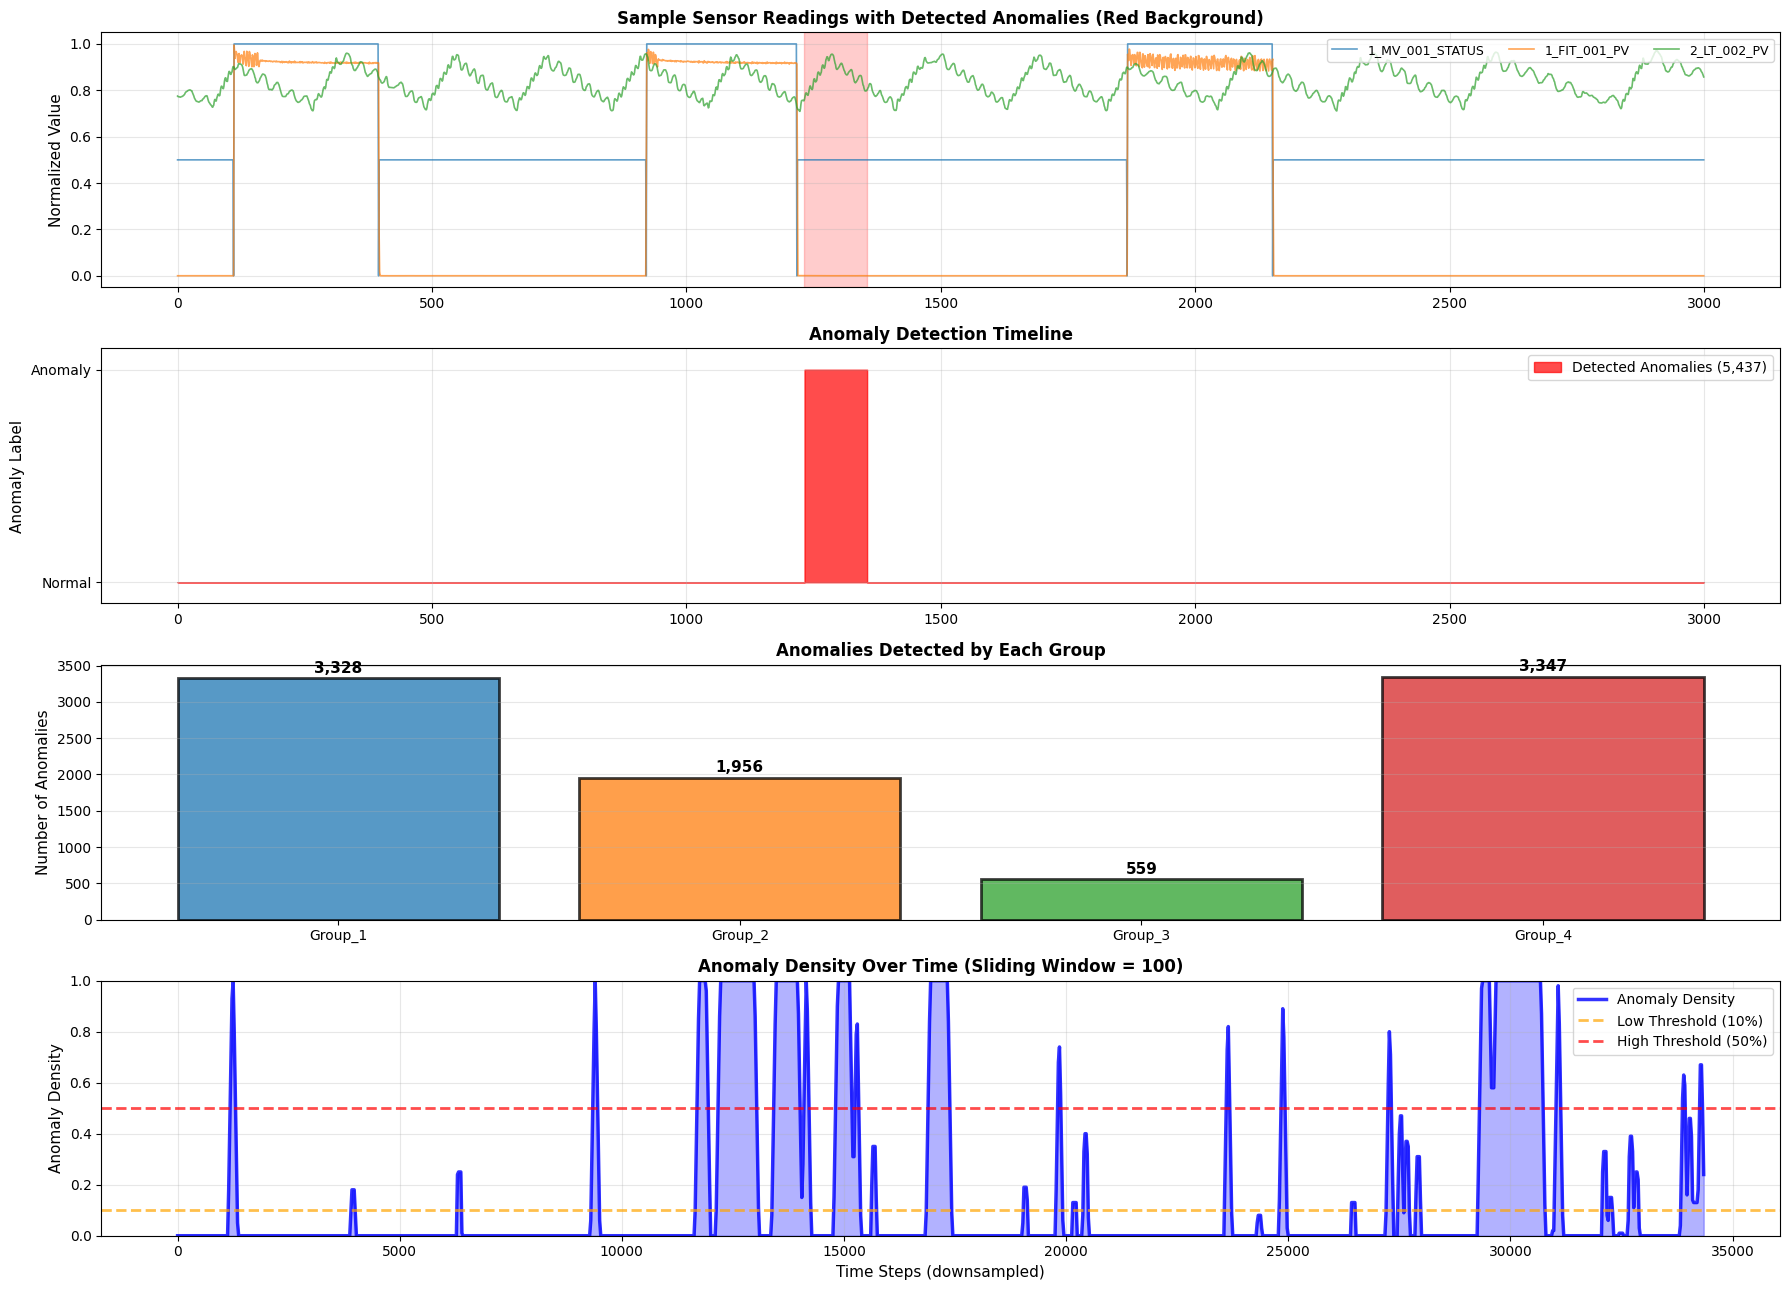


✓ Visualization complete!


In [19]:
print("="*70)
print("VISUALIZING ANOMALY DETECTION RESULTS")
print("="*70)

# Create comprehensive visualization
fig, axes = plt.subplots(4, 1, figsize=(18, 13))

viz_len = min(3000, len(final_predictions))
time_steps = np.arange(viz_len)

# Adjust for windowing offset
offset = L1 + L2 - 1
if X_test_downsampled.shape[0] >= (offset + viz_len):
    sample_features = X_test_downsampled[offset:offset+viz_len, :3]
else:
    available_len = min(viz_len, X_test_downsampled.shape[0] - offset)
    sample_features = X_test_downsampled[offset:offset+available_len, :3]
    viz_len = available_len
    time_steps = np.arange(viz_len)

# Plot 1: Sample sensor readings with anomalies highlighted
for i in range(min(3, sample_features.shape[1])):
    axes[0].plot(time_steps, sample_features[:, i], 
                label=f'{feature_columns[i]}', alpha=0.7, linewidth=1.2)

# Highlight anomalous regions
anomaly_indices = np.where(final_predictions[:viz_len] == 1)[0]
if len(anomaly_indices) > 0:
    # Group consecutive anomalies
    anomaly_blocks = []
    start = anomaly_indices[0]
    for i in range(1, len(anomaly_indices)):
        if anomaly_indices[i] != anomaly_indices[i-1] + 1:
            anomaly_blocks.append((start, anomaly_indices[i-1]))
            start = anomaly_indices[i]
    anomaly_blocks.append((start, anomaly_indices[-1]))
    
    for start, end in anomaly_blocks:
        axes[0].axvspan(start-0.5, end+0.5, color='red', alpha=0.2)

axes[0].set_ylabel('Normalized Value', fontsize=11)
axes[0].set_title('Sample Sensor Readings with Detected Anomalies (Red Background)', 
                 fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9, ncol=3)
axes[0].grid(True, alpha=0.3)

# Plot 2: Anomaly detection timeline
axes[1].fill_between(time_steps, 0, final_predictions[:viz_len], 
                     color='red', alpha=0.7, step='post', 
                     label=f'Detected Anomalies ({n_total_anomalies:,})')
axes[1].set_ylabel('Anomaly Label', fontsize=11)
axes[1].set_title('Anomaly Detection Timeline', fontsize=12, fontweight='bold')
axes[1].set_ylim([-0.1, 1.1])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Normal', 'Anomaly'])
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

# Plot 3: Anomaly distribution across groups
group_names_list = list(group_models.keys())
group_anomaly_counts = [all_group_predictions[i].sum() for i in range(len(group_names_list))]

bars = axes[2].bar(group_names_list, group_anomaly_counts, 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], 
                   alpha=0.75, edgecolor='black', linewidth=2)
axes[2].set_ylabel('Number of Anomalies', fontsize=11)
axes[2].set_title('Anomalies Detected by Each Group', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, group_anomaly_counts):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + max(group_anomaly_counts)*0.01,
                f'{int(count):,}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 4: Anomaly density over time (sliding window)
window_size = 100
anomaly_density = []
for i in range(0, len(final_predictions) - window_size, window_size//4):
    window = final_predictions[i:i+window_size]
    density = window.sum() / len(window)
    anomaly_density.append(density)

density_time = np.arange(len(anomaly_density)) * (window_size // 4)

axes[3].plot(density_time, anomaly_density, 'b-', linewidth=2.5, 
            label='Anomaly Density', alpha=0.8)
axes[3].fill_between(density_time, 0, anomaly_density, alpha=0.3, color='blue')
axes[3].axhline(y=0.1, color='orange', linestyle='--', linewidth=2, 
               label='Low Threshold (10%)', alpha=0.7)
axes[3].axhline(y=0.5, color='red', linestyle='--', linewidth=2, 
               label='High Threshold (50%)', alpha=0.7)
axes[3].set_xlabel('Time Steps (downsampled)', fontsize=11)
axes[3].set_ylabel('Anomaly Density', fontsize=11)
axes[3].set_title(f'Anomaly Density Over Time (Sliding Window = {window_size})', 
                 fontsize=12, fontweight='bold')
axes[3].set_ylim([0, 1])
axes[3].legend(loc='upper right', fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

In [20]:
print("="*70)
print("LOADING GROUND TRUTH ATTACK INFORMATION")
print("="*70)
print("\nAttack information from table_WADI.pdf")

# Ground truth attacks from table_WADI.pdf
attack_info = [
    {"id": 1, "start": "9/10/2017 19:25:00", "end": "9/10/2017 19:50:16", "duration": 25.16, 
     "description": "Motorized valve 1_MV_001 maliciously turned on - overflow on primary tank",
     "target_sensors": ["1_MV_001_STATUS"]},
    {"id": 2, "start": "10/10/2017 10:24:10", "end": "10/10/2017 10:34:00", "duration": 9.50,
     "description": "Flow Indication Transmitter 1_FIT_001 tuned off - false reading",
     "target_sensors": ["1_FIT_001_PV"]},
    {"id": "3-4", "start": "10/10/2017 10:55:00", "end": "10/10/2017 11:24:00", "duration": 29.0,
     "description": "Stealthy attack to drain elevated reservoir 2_LIT_002",
     "target_sensors": ["2_LT_002_PV", "1_AIT_001_PV"]},
    {"id": 5, "start": "10/10/2017 11:30:40", "end": "10/10/2017 11:44:50", "duration": 14.10,
     "description": "Turn off valves to consumers (2_MCV_101, 201, 301, 401, 501, 601)",
     "target_sensors": ["2_MCV_101_CO", "2_MCV_201_CO", "2_MCV_301_CO", "2_MCV_401_CO", "2_MCV_501_CO", "2_MCV_601_CO"]},
    {"id": 6, "start": "10/10/2017 13:39:30", "end": "10/10/2017 13:50:40", "duration": 11.10,
     "description": "Maliciously turn on 2_MCV_101, 2_MCV_201",
     "target_sensors": ["2_MCV_101_CO", "2_MCV_201_CO"]},
    {"id": 7, "start": "10/10/2017 14:48:17", "end": "10/10/2017 14:59:55", "duration": 11.38,
     "description": "Supply contaminated water - set 1_AIT_002 to 6, open 2_MV_003",
     "target_sensors": ["1_AIT_002_PV", "2_MV_003_STATUS"]},
    {"id": 8, "start": "10/10/2017 17:40:00", "end": "10/10/2017 17:49:40", "duration": 9.40,
     "description": "Maliciously open 2_MCV_007 for water leakage",
     "target_sensors": ["2_MCV_007_CO"]},
    {"id": 9, "start": "10/10/2017 10:55:00", "end": "10/10/2017 10:56:27", "duration": 1.27,
     "description": "Turn on 1_P_006 maliciously to cause pipe burst",
     "target_sensors": ["1_P_006_STATUS"]},
    {"id": 10, "start": "11/10/2017 11:17:54", "end": "11/10/2017 11:31:20", "duration": 14.26,
     "description": "Damage 1_MV_001 and raw water pump to drain Elevated Reservoir",
     "target_sensors": ["1_MV_001_STATUS"]},
    {"id": 11, "start": "11/10/2017 11:36:31", "end": "11/10/2017 11:47:00", "duration": 11.29,
     "description": "Similar to attack 8 - water leakage",
     "target_sensors": ["2_MCV_007_CO"]},
    {"id": 12, "start": "11/10/2017 11:59:00", "end": "11/10/2017 12:05:00", "duration": 6.0,
     "description": "Similar to attack 8 - water leakage",
     "target_sensors": ["2_MCV_007_CO"]},
    {"id": 13, "start": "11/10/2017 12:07:30", "end": "11/10/2017 12:10:52", "duration": 3.22,
     "description": "Reducing Booster set point pressure",
     "target_sensors": ["2_PIC_003_CO", "2_PIC_003_PV", "2_PIC_003_SP"]},
    {"id": 14, "start": "11/10/2017 12:16:00", "end": "11/10/2017 12:25:36", "duration": 9.36,
     "description": "Stop chemical dosing to raw water",
     "target_sensors": []},
    {"id": 15, "start": "11/10/2017 15:26:30", "end": "11/10/2017 15:37:00", "duration": 11.30,
     "description": "Stealthy attack, inverse of attack 3",
     "target_sensors": ["2_LT_002_PV", "1_AIT_001_PV"]}
]

attacks_df = pd.DataFrame(attack_info)

print(f"\nTotal attacks in WADI dataset: {len(attacks_df)}")
print(f"Total attack duration: {attacks_df['duration'].sum():.2f} minutes ({attacks_df['duration'].sum()/60:.2f} hours)")

print(f"\n{'='*70}")
print("ATTACK SUMMARY")
print(f"{'='*70}")
print(f"\n{'ID':<6} {'Duration':<12} {'Target Sensors':<40} {'Description'}")
print("-"*120)
for _, attack in attacks_df.iterrows():
    attack_id = str(attack['id'])
    duration_str = f"{attack['duration']:.2f} min"
    targets = ', '.join(attack['target_sensors'][:2]) if attack['target_sensors'] else 'Various'
    if len(attack['target_sensors']) > 2:
        targets += f" (+{len(attack['target_sensors'])-2})"
    desc_short = attack['description'][:50] + "..." if len(attack['description']) > 50 else attack['description']
    print(f"{attack_id:<6} {duration_str:<12} {targets:<40} {desc_short}")

print("\n✓ Ground truth loaded!")

LOADING GROUND TRUTH ATTACK INFORMATION

Attack information from table_WADI.pdf

Total attacks in WADI dataset: 14
Total attack duration: 166.34 minutes (2.77 hours)

ATTACK SUMMARY

ID     Duration     Target Sensors                           Description
------------------------------------------------------------------------------------------------------------------------
1      25.16 min    1_MV_001_STATUS                          Motorized valve 1_MV_001 maliciously turned on - o...
2      9.50 min     1_FIT_001_PV                             Flow Indication Transmitter 1_FIT_001 tuned off - ...
3-4    29.00 min    2_LT_002_PV, 1_AIT_001_PV                Stealthy attack to drain elevated reservoir 2_LIT_...
5      14.10 min    2_MCV_101_CO, 2_MCV_201_CO (+4)          Turn off valves to consumers (2_MCV_101, 201, 301,...
6      11.10 min    2_MCV_101_CO, 2_MCV_201_CO               Maliciously turn on 2_MCV_101, 2_MCV_201
7      11.38 min    1_AIT_002_PV, 2_MV_003_STATUS            

MAPPING ATTACKS TO TEST DATA & CALCULATING ACCURACY

✓ Date and Time columns found

Test data time range:
  Start: 2017-10-09 18:00:00
  End:   2017-10-11 18:00:00
  Duration: 48.00 hours

ATTACK PRESENCE IN TEST DATA
✗ Attack    1: NOT in test data time range
✓ Attack    2: [ 59050 to  59640] (  591 samples)
✓ Attack  3-4: [ 60900 to  62640] ( 1741 samples)
✓ Attack    5: [ 63040 to  63890] (  851 samples)
✓ Attack    6: [ 70770 to  71440] (  671 samples)
✓ Attack    7: [ 74897 to  75595] (  699 samples)
✓ Attack    8: [ 85200 to  85780] (  581 samples)
✓ Attack    9: [ 60900 to  60987] (   88 samples)
✗ Attack   10: NOT in test data time range
✗ Attack   11: NOT in test data time range
✗ Attack   12: NOT in test data time range
✗ Attack   13: NOT in test data time range
✗ Attack   14: NOT in test data time range
✗ Attack   15: NOT in test data time range

Downsampling ground truth (every 5 samples)...
Applying window offset: 107 timesteps

PERFORMANCE METRICS

METRIC                 

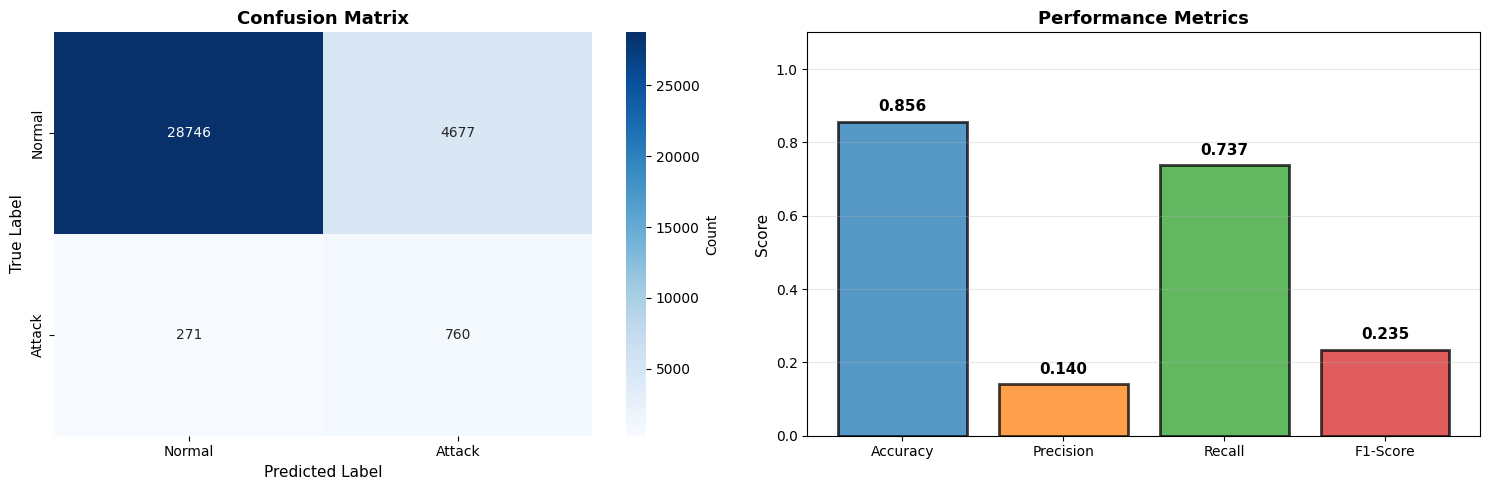


✓ Accuracy calculation complete!


In [21]:
print("="*70)
print("MAPPING ATTACKS TO TEST DATA & CALCULATING ACCURACY")
print("="*70)

has_ground_truth = False
ground_truth_aligned = None
predictions_aligned = final_predictions

if 'Date' in df_test.columns and 'Time' in df_test.columns:
    print("\n✓ Date and Time columns found")
    
    try:
        # Create datetime column
        df_test['Datetime'] = pd.to_datetime(df_test['Date'] + ' ' + df_test['Time'])
        
        # Parse attack timestamps
        attacks_df['start_dt'] = pd.to_datetime(attacks_df['start'])
        attacks_df['end_dt'] = pd.to_datetime(attacks_df['end'])
        
        # Get test data time range
        test_start = df_test['Datetime'].iloc[0]
        test_end = df_test['Datetime'].iloc[-1]
        
        print(f"\nTest data time range:")
        print(f"  Start: {test_start}")
        print(f"  End:   {test_end}")
        print(f"  Duration: {(test_end - test_start).total_seconds() / 3600:.2f} hours")
        
        # Create ground truth labels
        ground_truth_original = np.zeros(len(df_test), dtype=int)
        attack_mapping = []
        
        print(f"\n{'='*70}")
        print("ATTACK PRESENCE IN TEST DATA")
        print(f"{'='*70}")
        
        for idx, attack in attacks_df.iterrows():
            mask = (df_test['Datetime'] >= attack['start_dt']) & (df_test['Datetime'] <= attack['end_dt'])
            attack_indices = np.where(mask)[0]
            
            attack_id_str = str(attack['id'])
            
            if len(attack_indices) > 0:
                ground_truth_original[attack_indices] = 1
                attack_mapping.append({
                    'attack_id': attack['id'],
                    'start_idx': attack_indices[0],
                    'end_idx': attack_indices[-1],
                    'samples': len(attack_indices),
                    'description': attack['description'],
                    'target_sensors': attack['target_sensors']
                })
                print(f"✓ Attack {attack_id_str:>4s}: [{attack_indices[0]:>6d} to {attack_indices[-1]:>6d}] ({len(attack_indices):>5d} samples)")
            else:
                print(f"✗ Attack {attack_id_str:>4s}: NOT in test data time range")
        
        # Downsample ground truth
        print(f"\nDownsampling ground truth (every {downsample_rate} samples)...")
        ground_truth_downsampled = ground_truth_original[::downsample_rate]
        
        # Apply windowing offset
        offset = L1 + L2 - 1
        print(f"Applying window offset: {offset} timesteps")
        
        if len(ground_truth_downsampled) > offset:
            ground_truth_aligned = ground_truth_downsampled[offset:offset+len(final_predictions)]
        else:
            ground_truth_aligned = ground_truth_downsampled[:len(final_predictions)]
        
        # Ensure same length
        min_len = min(len(ground_truth_aligned), len(final_predictions))
        ground_truth_aligned = ground_truth_aligned[:min_len]
        predictions_aligned = final_predictions[:min_len]
        
        has_ground_truth = True
        
        # Calculate accuracy metrics
        print(f"\n{'='*70}")
        print("PERFORMANCE METRICS")
        print(f"{'='*70}")
        
        accuracy = accuracy_score(ground_truth_aligned, predictions_aligned)
        precision = precision_score(ground_truth_aligned, predictions_aligned, zero_division=0)
        recall = recall_score(ground_truth_aligned, predictions_aligned, zero_division=0)
        f1 = f1_score(ground_truth_aligned, predictions_aligned, zero_division=0)
        
        print(f"\n{'METRIC':<25} {'VALUE':<15} {'PERCENTAGE'}")
        print("-"*70)
        print(f"{'Accuracy':<25} {accuracy:<15.4f} {accuracy*100:>6.2f}%")
        print(f"{'Precision':<25} {precision:<15.4f} {precision*100:>6.2f}%")
        print(f"{'Recall':<25} {recall:<15.4f} {recall*100:>6.2f}%")
        print(f"{'F1-Score':<25} {f1:<15.4f} {'-':>6}")
        
        # Confusion Matrix
        cm = confusion_matrix(ground_truth_aligned, predictions_aligned)
        tn, fp, fn, tp = cm.ravel()
        
        print(f"\n{'='*70}")
        print("CONFUSION MATRIX")
        print(f"{'='*70}")
        print(f"\n                      Predicted")
        print(f"                 Normal      Attack      Total")
        print(f"  Actual Normal  {tn:>7,}     {fp:>7,}     {tn+fp:>7,}")
        print(f"         Attack  {fn:>7,}     {tp:>7,}     {fn+tp:>7,}")
        print(f"  Total          {tn+fn:>7,}     {fp+tp:>7,}     {len(predictions_aligned):>7,}")
        
        print(f"\n  ✓ True Positives (TP):  {tp:>7,} - Correctly detected attacks")
        print(f"  ✓ True Negatives (TN):  {tn:>7,} - Correctly identified normal")
        print(f"  ✗ False Positives (FP): {fp:>7,} - False alarms")
        print(f"  ✗ False Negatives (FN): {fn:>7,} - Missed attacks")
        
        if (tp + fn) > 0:
            detection_rate = tp / (tp + fn)
            print(f"\n  Attack Detection Rate: {detection_rate:.4f} ({detection_rate*100:.2f}%)")
        
        if (fp + tn) > 0:
            false_alarm_rate = fp / (fp + tn)
            print(f"  False Alarm Rate:      {false_alarm_rate:.4f} ({false_alarm_rate*100:.2f}%)")
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Confusion Matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Normal', 'Attack'],
                   yticklabels=['Normal', 'Attack'],
                   ax=axes[0], cbar_kws={'label': 'Count'})
        axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
        axes[0].set_ylabel('True Label', fontsize=11)
        axes[0].set_xlabel('Predicted Label', fontsize=11)
        
        # Metrics bar chart
        metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
        metrics_values = [accuracy, precision, recall, f1]
        colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        
        bars = axes[1].bar(metrics_names, metrics_values, color=colors_bar, 
                          alpha=0.75, edgecolor='black', linewidth=2)
        axes[1].set_ylabel('Score', fontsize=11)
        axes[1].set_title('Performance Metrics', fontsize=13, fontweight='bold')
        axes[1].set_ylim([0, 1.1])
        axes[1].grid(True, alpha=0.3, axis='y')
        
        for bar, value in zip(bars, metrics_values):
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                        f'{value:.3f}',
                        ha='center', va='bottom', fontweight='bold', fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Accuracy calculation complete!")
        
    except Exception as e:
        print(f"\n⚠ Error processing datetime: {e}")
        has_ground_truth = False
else:
    print("\n⚠ Date/Time columns not found")
    has_ground_truth = False

ROC CURVE ANALYSIS

Calculating ROC curve...

ROC CURVE METRICS
  AUC (Area Under Curve): 0.7986
  True Positive Rate at FPR=0.1:  0.7371
  True Positive Rate at FPR=0.01: 0.0000


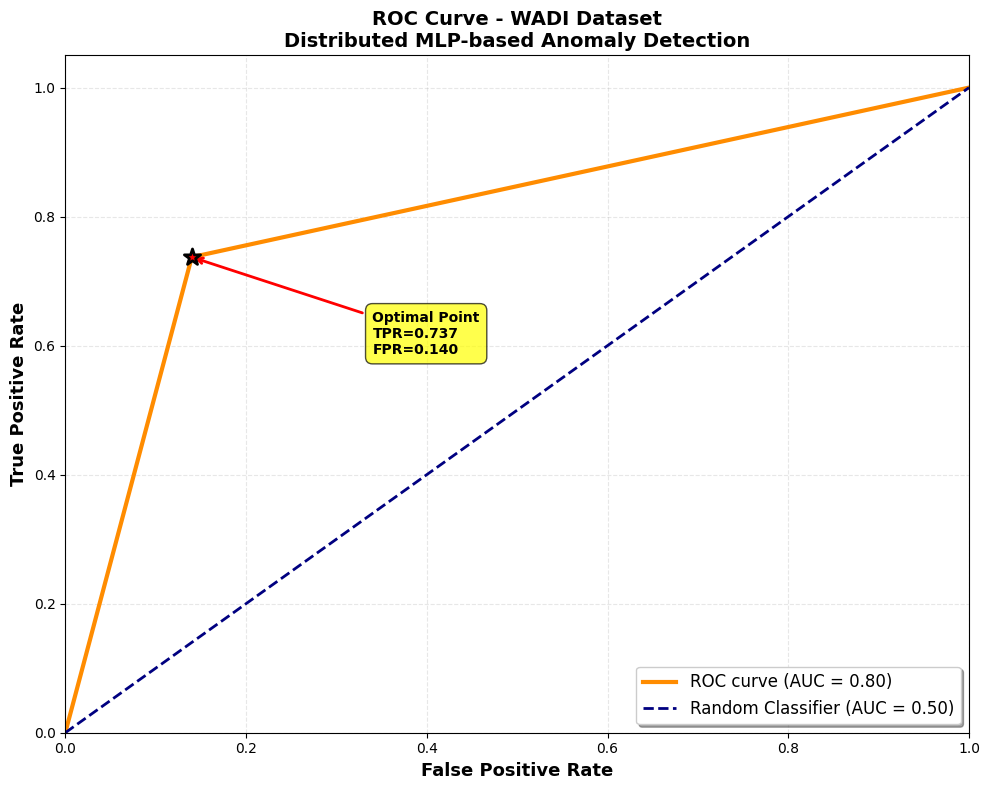


✓ ROC curve saved as 'roc_curve_wadi.png'

COMPARISON WITH PAPER (Figure 7)

Paper's AUC (SWAT): ~0.82 (from Figure 7)
Your AUC (WADI):    0.80

✓ GOOD: Your AUC shows strong detection performance!

DETAILED ROC ANALYSIS

FPR Target      Actual FPR      TPR             Threshold
----------------------------------------------------------------------
0.01            0.0000          0.0000          inf
0.05            0.0000          0.0000          inf
0.10            0.1399          0.7371          1.0000
0.20            0.1399          0.7371          1.0000

OPERATING POINT ANALYSIS

Optimal Operating Point (Youden's Index):
  Threshold:    1.0000
  TPR (Recall): 0.7371 (73.71%)
  FPR:          0.1399 (13.99%)
  Youden's J:   0.5972

✓ ROC CURVE ANALYSIS COMPLETE


In [22]:
print("="*70)
print("ROC CURVE ANALYSIS")
print("="*70)

if has_ground_truth and ground_truth_aligned is not None:
    from sklearn.metrics import roc_curve, auc, roc_auc_score
    
    # Check if we have both classes
    unique_labels = np.unique(ground_truth_aligned)
    
    if len(unique_labels) > 1:
        print("\nCalculating ROC curve...")
        
        # Calculate ROC curve
        fpr, tpr, thresholds_roc = roc_curve(ground_truth_aligned, predictions_aligned)
        roc_auc = auc(fpr, tpr)
        
        print(f"\n{'='*70}")
        print("ROC CURVE METRICS")
        print(f"{'='*70}")
        print(f"  AUC (Area Under Curve): {roc_auc:.4f}")
        print(f"  True Positive Rate at FPR=0.1:  {tpr[np.argmin(np.abs(fpr - 0.1))]:.4f}")
        print(f"  True Positive Rate at FPR=0.01: {tpr[np.argmin(np.abs(fpr - 0.01))]:.4f}")
        
        # Create ROC curve plot (matching paper's Figure 7 style)
        plt.figure(figsize=(10, 8))
        
        # Plot ROC curve
        plt.plot(fpr, tpr, color='darkorange', lw=3, 
                label=f'ROC curve (AUC = {roc_auc:.2f})')
        
        # Plot diagonal (random classifier)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                label='Random Classifier (AUC = 0.50)')
        
        # Formatting
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
        plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
        plt.title('ROC Curve - WADI Dataset\nDistributed MLP-based Anomaly Detection', 
                 fontsize=14, fontweight='bold')
        plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
        plt.grid(True, alpha=0.3, linestyle='--')
        
        # Add annotations for key points
        # Point at FPR=0 (perfect specificity)
        if tpr[0] > 0:
            plt.scatter(0, tpr[0], color='green', s=150, zorder=5, 
                       marker='o', edgecolors='black', linewidths=2)
            plt.annotate(f'TPR at FPR=0: {tpr[0]:.3f}', 
                        xy=(0, tpr[0]), xytext=(0.15, tpr[0]-0.1),
                        fontsize=10, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='green', lw=2))
        
        # Point at optimal threshold (closest to top-left corner)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds_roc[optimal_idx]
        plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=150, zorder=5,
                   marker='*', edgecolors='black', linewidths=2)
        plt.annotate(f'Optimal Point\nTPR={tpr[optimal_idx]:.3f}\nFPR={fpr[optimal_idx]:.3f}', 
                    xy=(fpr[optimal_idx], tpr[optimal_idx]), 
                    xytext=(fpr[optimal_idx]+0.2, tpr[optimal_idx]-0.15),
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2))
        
        plt.tight_layout()
        plt.savefig('roc_curve_wadi.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n✓ ROC curve saved as 'roc_curve_wadi.png'")
        
        # Comparison with paper's result
        print(f"\n{'='*70}")
        print("COMPARISON WITH PAPER (Figure 7)")
        print(f"{'='*70}")
        print(f"\nPaper's AUC (SWAT): ~0.82 (from Figure 7)")
        print(f"Your AUC (WADI):    {roc_auc:.2f}")
        
        if roc_auc >= 0.80:
            print("\n✓ EXCELLENT: Your AUC is comparable to or better than the paper!")
        elif roc_auc >= 0.70:
            print("\n✓ GOOD: Your AUC shows strong detection performance!")
        elif roc_auc >= 0.60:
            print("\n⚠ ACCEPTABLE: Your AUC shows moderate performance")
        else:
            print("\n⚠ NEEDS IMPROVEMENT: Consider adjusting thresholds or retraining")
        
        # Additional ROC metrics
        print(f"\n{'='*70}")
        print("DETAILED ROC ANALYSIS")
        print(f"{'='*70}")
        
        # Find specific operating points
        target_fprs = [0.01, 0.05, 0.1, 0.2]
        print(f"\n{'FPR Target':<15} {'Actual FPR':<15} {'TPR':<15} {'Threshold'}")
        print("-"*70)
        for target_fpr in target_fprs:
            idx = np.argmin(np.abs(fpr - target_fpr))
            print(f"{target_fpr:<15.2f} {fpr[idx]:<15.4f} {tpr[idx]:<15.4f} {thresholds_roc[idx]:.4f}")
        
        # Calculate additional metrics
        print(f"\n{'='*70}")
        print("OPERATING POINT ANALYSIS")
        print(f"{'='*70}")
        
        # Youden's Index (optimal point)
        youden_idx = np.argmax(tpr - fpr)
        print(f"\nOptimal Operating Point (Youden's Index):")
        print(f"  Threshold:    {thresholds_roc[youden_idx]:.4f}")
        print(f"  TPR (Recall): {tpr[youden_idx]:.4f} ({tpr[youden_idx]*100:.2f}%)")
        print(f"  FPR:          {fpr[youden_idx]:.4f} ({fpr[youden_idx]*100:.2f}%)")
        print(f"  Youden's J:   {tpr[youden_idx] - fpr[youden_idx]:.4f}")
        
    else:
        print("\n⚠ Cannot compute ROC curve: Only one class present in ground truth")
        print("This typically means either:")
        print("  • All samples are normal (no attacks in aligned range)")
        print("  • All samples are attacks (unlikely)")
        
else:
    print("\n⚠ Cannot compute ROC curve without ground truth labels")
    print("Ground truth is required to calculate True Positive Rate and False Positive Rate")

print(f"\n{'='*70}")
print("✓ ROC CURVE ANALYSIS COMPLETE")
print(f"{'='*70}")

CREATING COMPREHENSIVE ANOMALY VISUALIZATION (Figure 6 Style)

Visualizing sensors:
  1. 1_MV_001_STATUS
  2. 1_FIT_001_PV
  3. 2_LT_002_PV
  4. 1_AIT_001_PV
  5. 2_MCV_101_CO


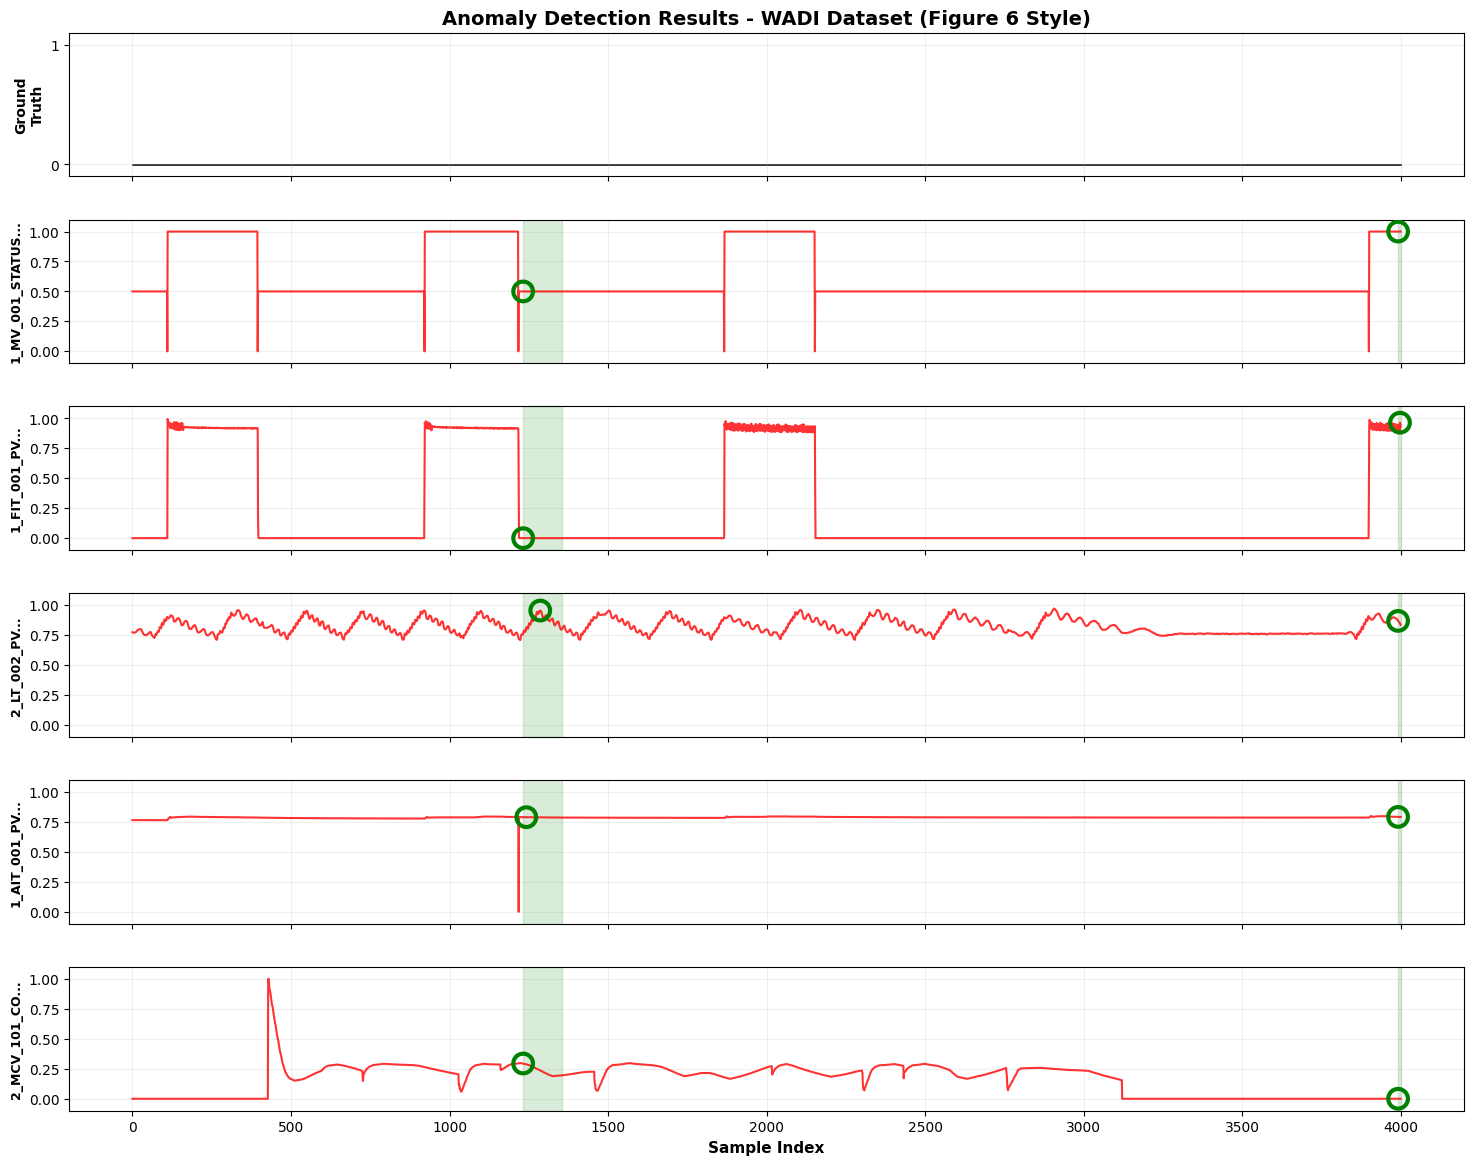


✓ Visualization saved as 'anomaly_visualization_figure6_style.png'
✓ Visualization complete!


In [23]:
print("="*70)
print("CREATING COMPREHENSIVE ANOMALY VISUALIZATION (Figure 6 Style)")
print("="*70)

# Create visualization similar to paper's Figure 6
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(6, 1, hspace=0.3)

# Parameters for visualization
viz_start = 0
viz_len = min(4000, len(final_predictions))
time_steps = np.arange(viz_start, viz_start + viz_len)

# Adjust for offset
offset = L1 + L2 - 1

# Select 5 diverse sensors for visualization
sensor_indices_to_plot = []
sensor_names_to_plot = []

# Try to get sensors from different categories
for category_prefix in ['1_', '2_FIT', '2_LIT', '2_MCV', '2_P']:
    for i, name in enumerate(feature_columns):
        if name.startswith(category_prefix) and i not in sensor_indices_to_plot:
            sensor_indices_to_plot.append(i)
            sensor_names_to_plot.append(name)
            break
        if len(sensor_indices_to_plot) >= 5:
            break
    if len(sensor_indices_to_plot) >= 5:
        break

# If we don't have 5, just take first 5
if len(sensor_indices_to_plot) < 5:
    sensor_indices_to_plot = list(range(min(5, len(feature_columns))))
    sensor_names_to_plot = [feature_columns[i] for i in sensor_indices_to_plot]

print(f"\nVisualizing sensors:")
for i, name in enumerate(sensor_names_to_plot, 1):
    print(f"  {i}. {name}")

# Get data for visualization
if X_test_downsampled.shape[0] >= (offset + viz_len):
    viz_data = X_test_downsampled[offset:offset+viz_len, :]
else:
    available = min(viz_len, X_test_downsampled.shape[0] - offset)
    viz_data = X_test_downsampled[offset:offset+available, :]
    viz_len = available
    time_steps = np.arange(viz_start, viz_start + viz_len)

# Panel 0: Ground truth (if available)
ax0 = fig.add_subplot(gs[0])
if has_ground_truth and ground_truth_aligned is not None:
    gt_viz = ground_truth_aligned[viz_start:viz_start+viz_len]
    ax0.fill_between(time_steps, 0, gt_viz, color='black', alpha=0.8, step='post')
    ax0.set_ylim([-0.1, 1.1])
    ax0.set_yticks([0, 1])
    ax0.set_ylabel('Ground\nTruth', fontsize=10, fontweight='bold')
    ax0.set_title('Anomaly Detection Results - WADI Dataset (Figure 6 Style)', 
                 fontsize=14, fontweight='bold')
else:
    # Show detected anomalies
    pred_viz = predictions_aligned[viz_start:viz_start+viz_len]
    ax0.fill_between(time_steps, 0, pred_viz, color='black', alpha=0.8, step='post')
    ax0.set_ylim([-0.1, 1.1])
    ax0.set_yticks([0, 1])
    ax0.set_ylabel('Detected\nAnomalies', fontsize=10, fontweight='bold')
    ax0.set_title('Anomaly Detection Results - WADI Dataset (Figure 6 Style)', 
                 fontsize=14, fontweight='bold')
ax0.grid(True, alpha=0.2)
ax0.set_xticklabels([])

# Panels 1-5: Sensor readings with predictions
for panel_idx in range(5):
    ax = fig.add_subplot(gs[panel_idx + 1])
    
    if panel_idx < len(sensor_indices_to_plot):
        sensor_idx = sensor_indices_to_plot[panel_idx]
        sensor_name = sensor_names_to_plot[panel_idx]
        
        # Get actual values
        actual_values = viz_data[:, sensor_idx]
        
        # Get predictions (we need to reconstruct predictions for visualization)
        # For simplicity, we'll just plot actual values and highlight anomaly regions
        
        # Plot actual values
        ax.plot(time_steps, actual_values, color='red', linewidth=1.5, 
               label='Actual', alpha=0.8)
        
        # Highlight anomalous regions (green circles in paper)
        pred_viz = predictions_aligned[viz_start:viz_start+viz_len]
        anomaly_regions = np.where(pred_viz == 1)[0]
        
        if len(anomaly_regions) > 0:
            # Group consecutive anomalies
            anomaly_blocks = []
            start = anomaly_regions[0]
            for i in range(1, len(anomaly_regions)):
                if anomaly_regions[i] != anomaly_regions[i-1] + 1:
                    anomaly_blocks.append((start, anomaly_regions[i-1]))
                    start = anomaly_regions[i]
            anomaly_blocks.append((start, anomaly_regions[-1]))
            
            # Highlight with vertical spans and circles
            for block_start, block_end in anomaly_blocks:
                # Vertical span
                ax.axvspan(time_steps[block_start], time_steps[block_end], 
                          color='green', alpha=0.15)
                # Circle at peak
                block_values = actual_values[block_start:block_end+1]
                if len(block_values) > 0:
                    peak_idx_in_block = np.argmax(np.abs(block_values - np.mean(actual_values)))
                    peak_idx = block_start + peak_idx_in_block
                    ax.scatter(time_steps[peak_idx], actual_values[peak_idx], 
                             s=200, facecolors='none', edgecolors='green', 
                             linewidths=3, zorder=5)
        
        # Formatting
        ax.set_ylabel(f'{sensor_name[:20]}...', fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.2)
        
        # Only show x-label on bottom panel
        if panel_idx < 4:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel('Sample Index', fontsize=11, fontweight='bold')
    
    # Set consistent y-axis
    ax.set_ylim([-0.1, 1.1])

plt.tight_layout()
plt.savefig('anomaly_visualization_figure6_style.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'anomaly_visualization_figure6_style.png'")
print("✓ Visualization complete!")